Chapter 7: Finetuning To Follow Instructions

In [ ]:
# 检查本章依赖的第三方库版本，避免版本不兼容导致后续代码运行异常
from importlib.metadata import version

pkgs = [
    "numpy",       # PyTorch & TensorFlow dependency
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

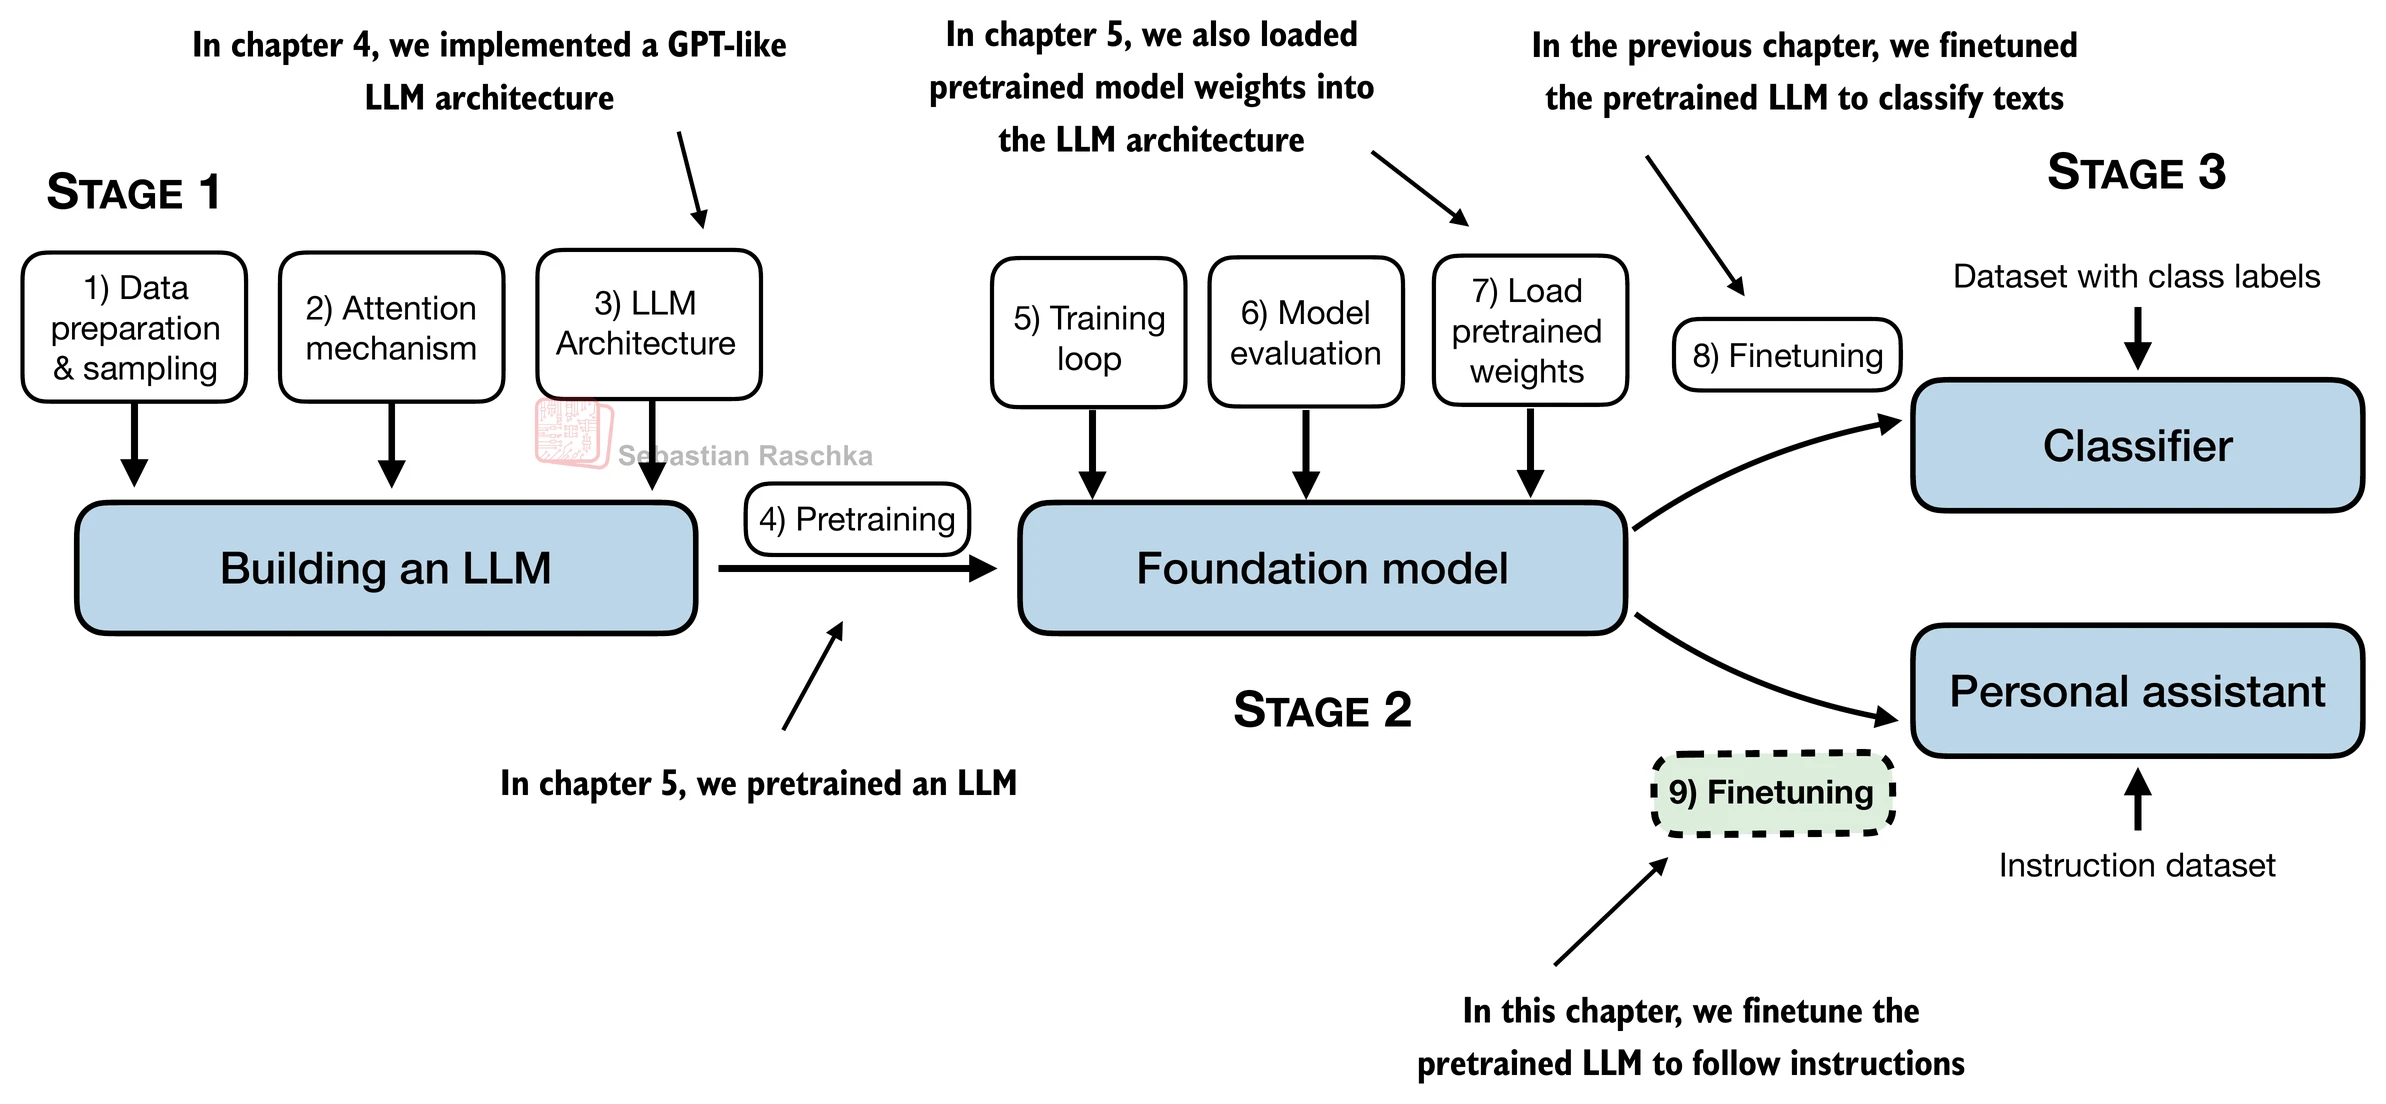

7.1 Introduction to instruction finetuning
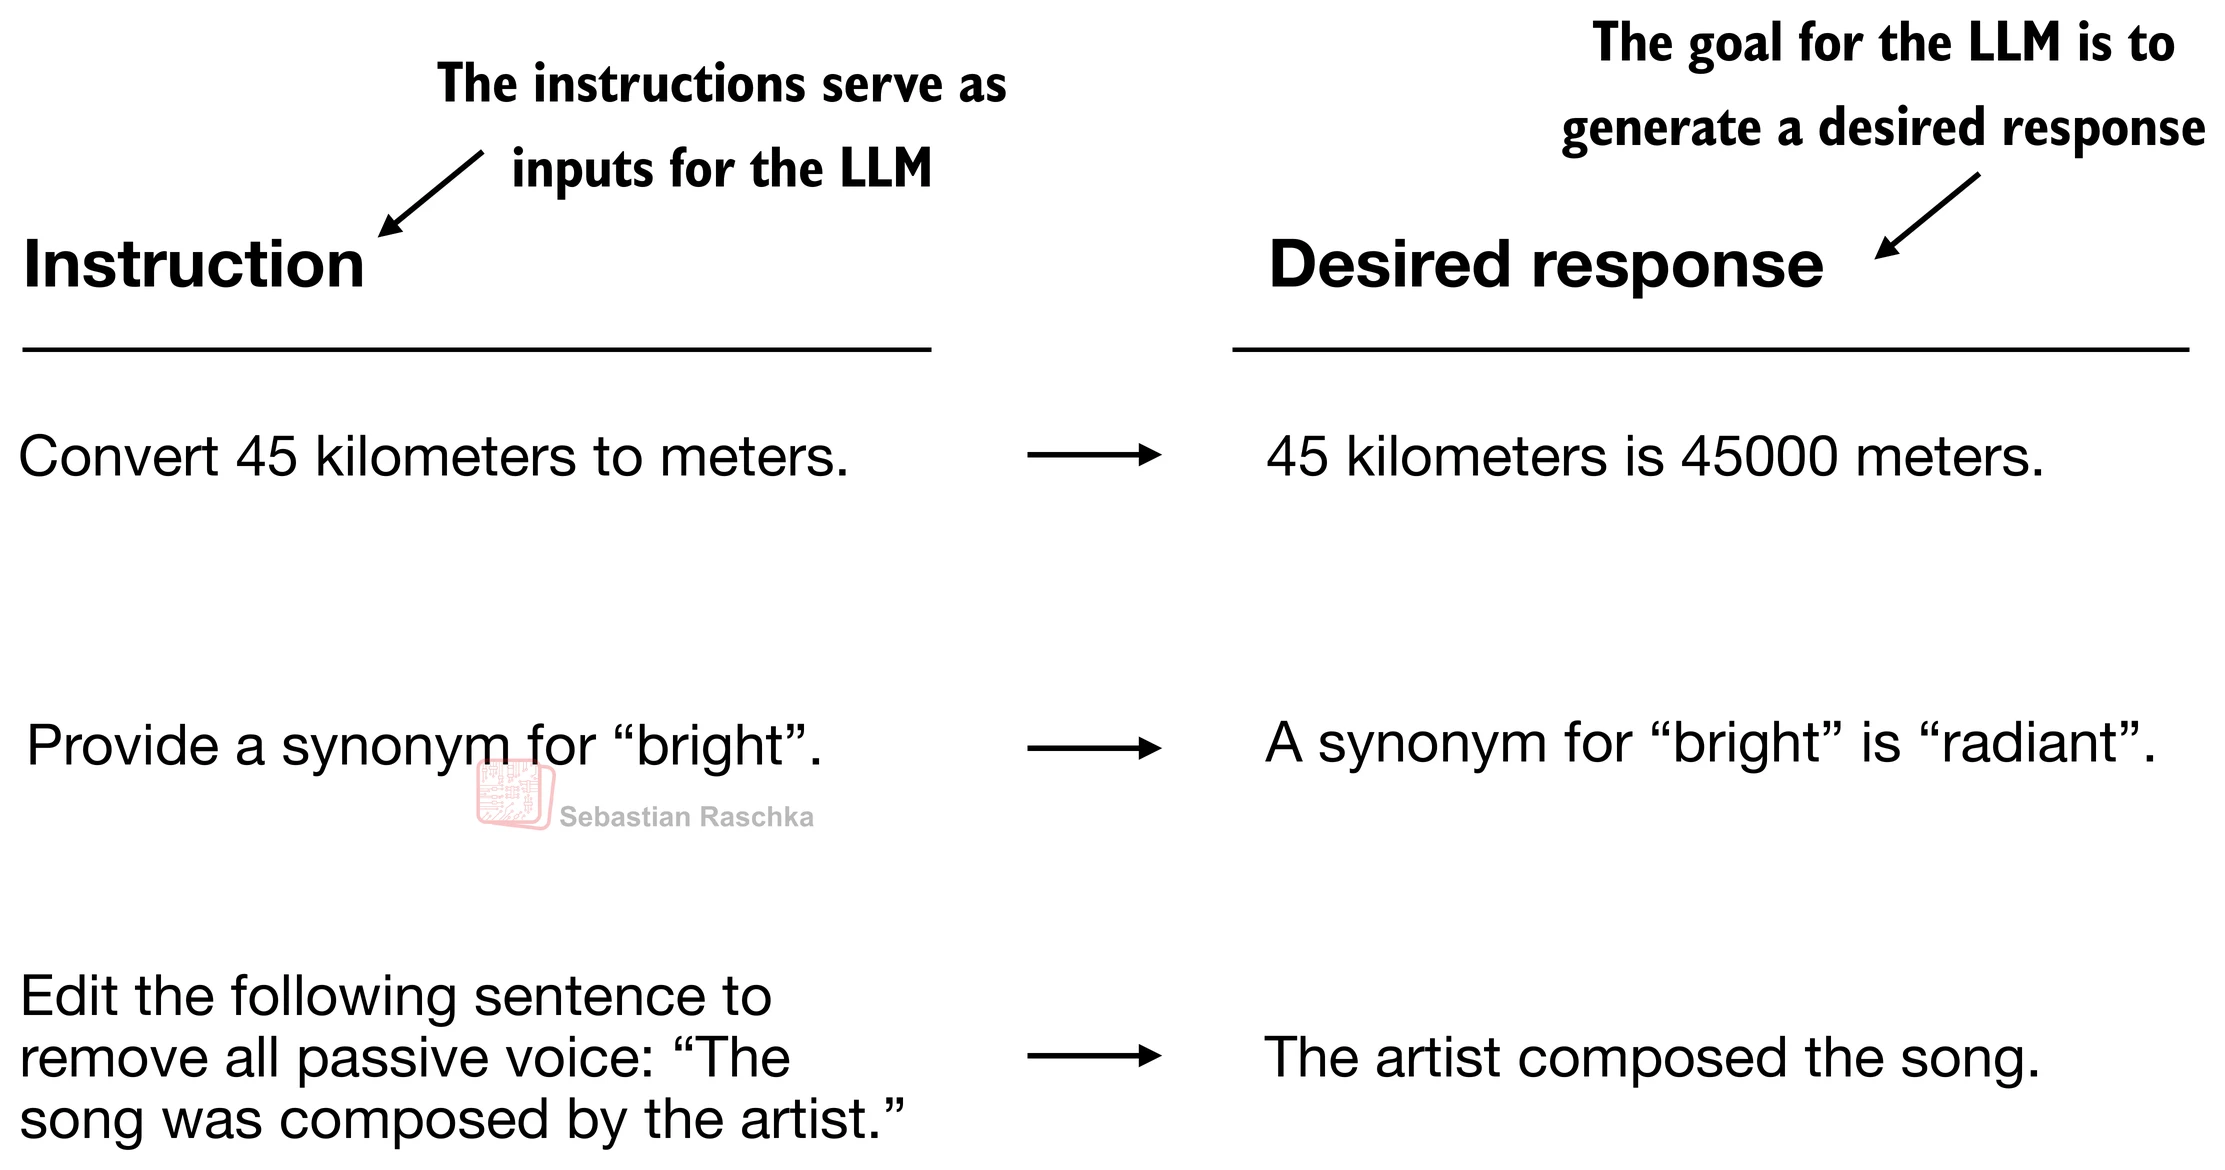
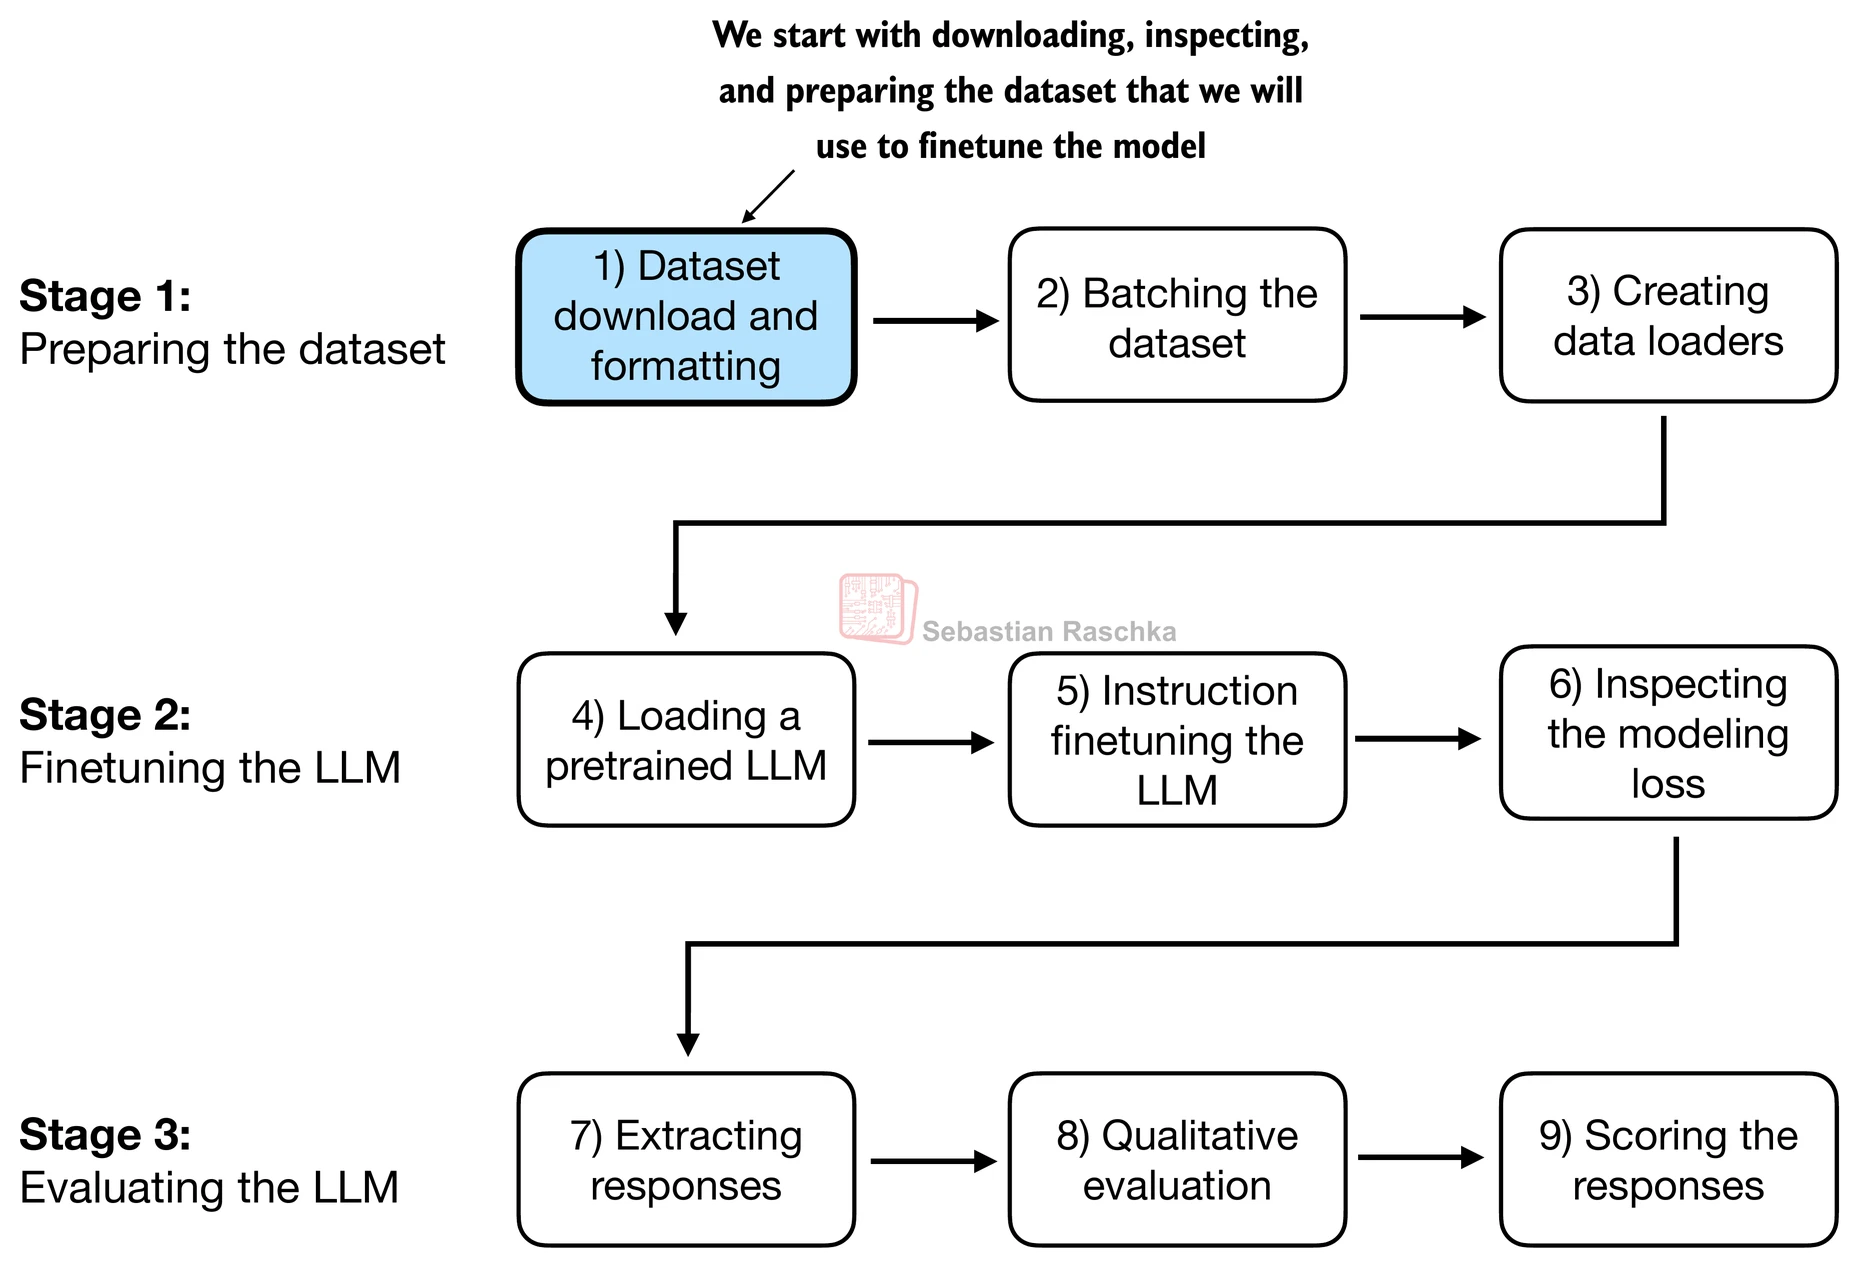

7.2 Preparing a dataset for supervised instruction finetuning

In [ ]:
# 定义下载并加载指令微调数据集的函数：若本地文件不存在则从远程 URL 下载并写入本地缓存，
# 然后统一从本地文件读取 JSON，返回 Python list（每个元素是一个 dict，含 instruction/input/output 字段）
import json
import os
import requests

def download_and_load_file(file_path,url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data
# The book originally used the following code below
# However, urllib uses older protocol settings that
# can cause problems for some readers using a VPN.
# The `requests` version above is more robust
# in that regard.

"""
import urllib

def download_and_load_file(file_path, url):

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data
"""


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

# 实际下载/加载指令数据集，data 是包含约 1100 条指令样本的 list[dict]
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

In [ ]:
# 查看第 50 条样本的原始结构（dict，含 instruction / input / output 字段）
print("Example entry:\n", data[50])

In [ ]:
# 再看第 999 条样本，注意其 input 字段可能为空字符串（无附加输入的任务）
print("Another example entry:\n", data[999])

In [ ]:
# 定义 Alpaca 风格的 prompt 格式化函数：将 instruction（和可选的 input）拼接成
# 固定模板的指令文本，模型将在此基础上续写 "### Response:" 之后的内容
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    # 只有当 input 字段非空时才附加 "### Input:" 段落，否则该部分为空字符串
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [ ]:
# 拼接完整的 “提示词 + 期望回答”，用于直观展示训练时模型应学习生成的目标文本格式
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

In [ ]:
# 同样拼接第 999 条样本（该条 input 为空），观察模板在无 Input 段落时的效果
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

In [ ]:
# 按 85% / 10% / 5% 的比例切分训练集、测试集、验证集（注意：先切训练集和测试集，
# 剩余部分作为验证集，因此 val_portion 是用总长度减去前两者得到的，非独立计算）
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [ ]:
# 打印各子集的样本数量，核对切分比例是否符合预期
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

7.3 Organizing data into training batches
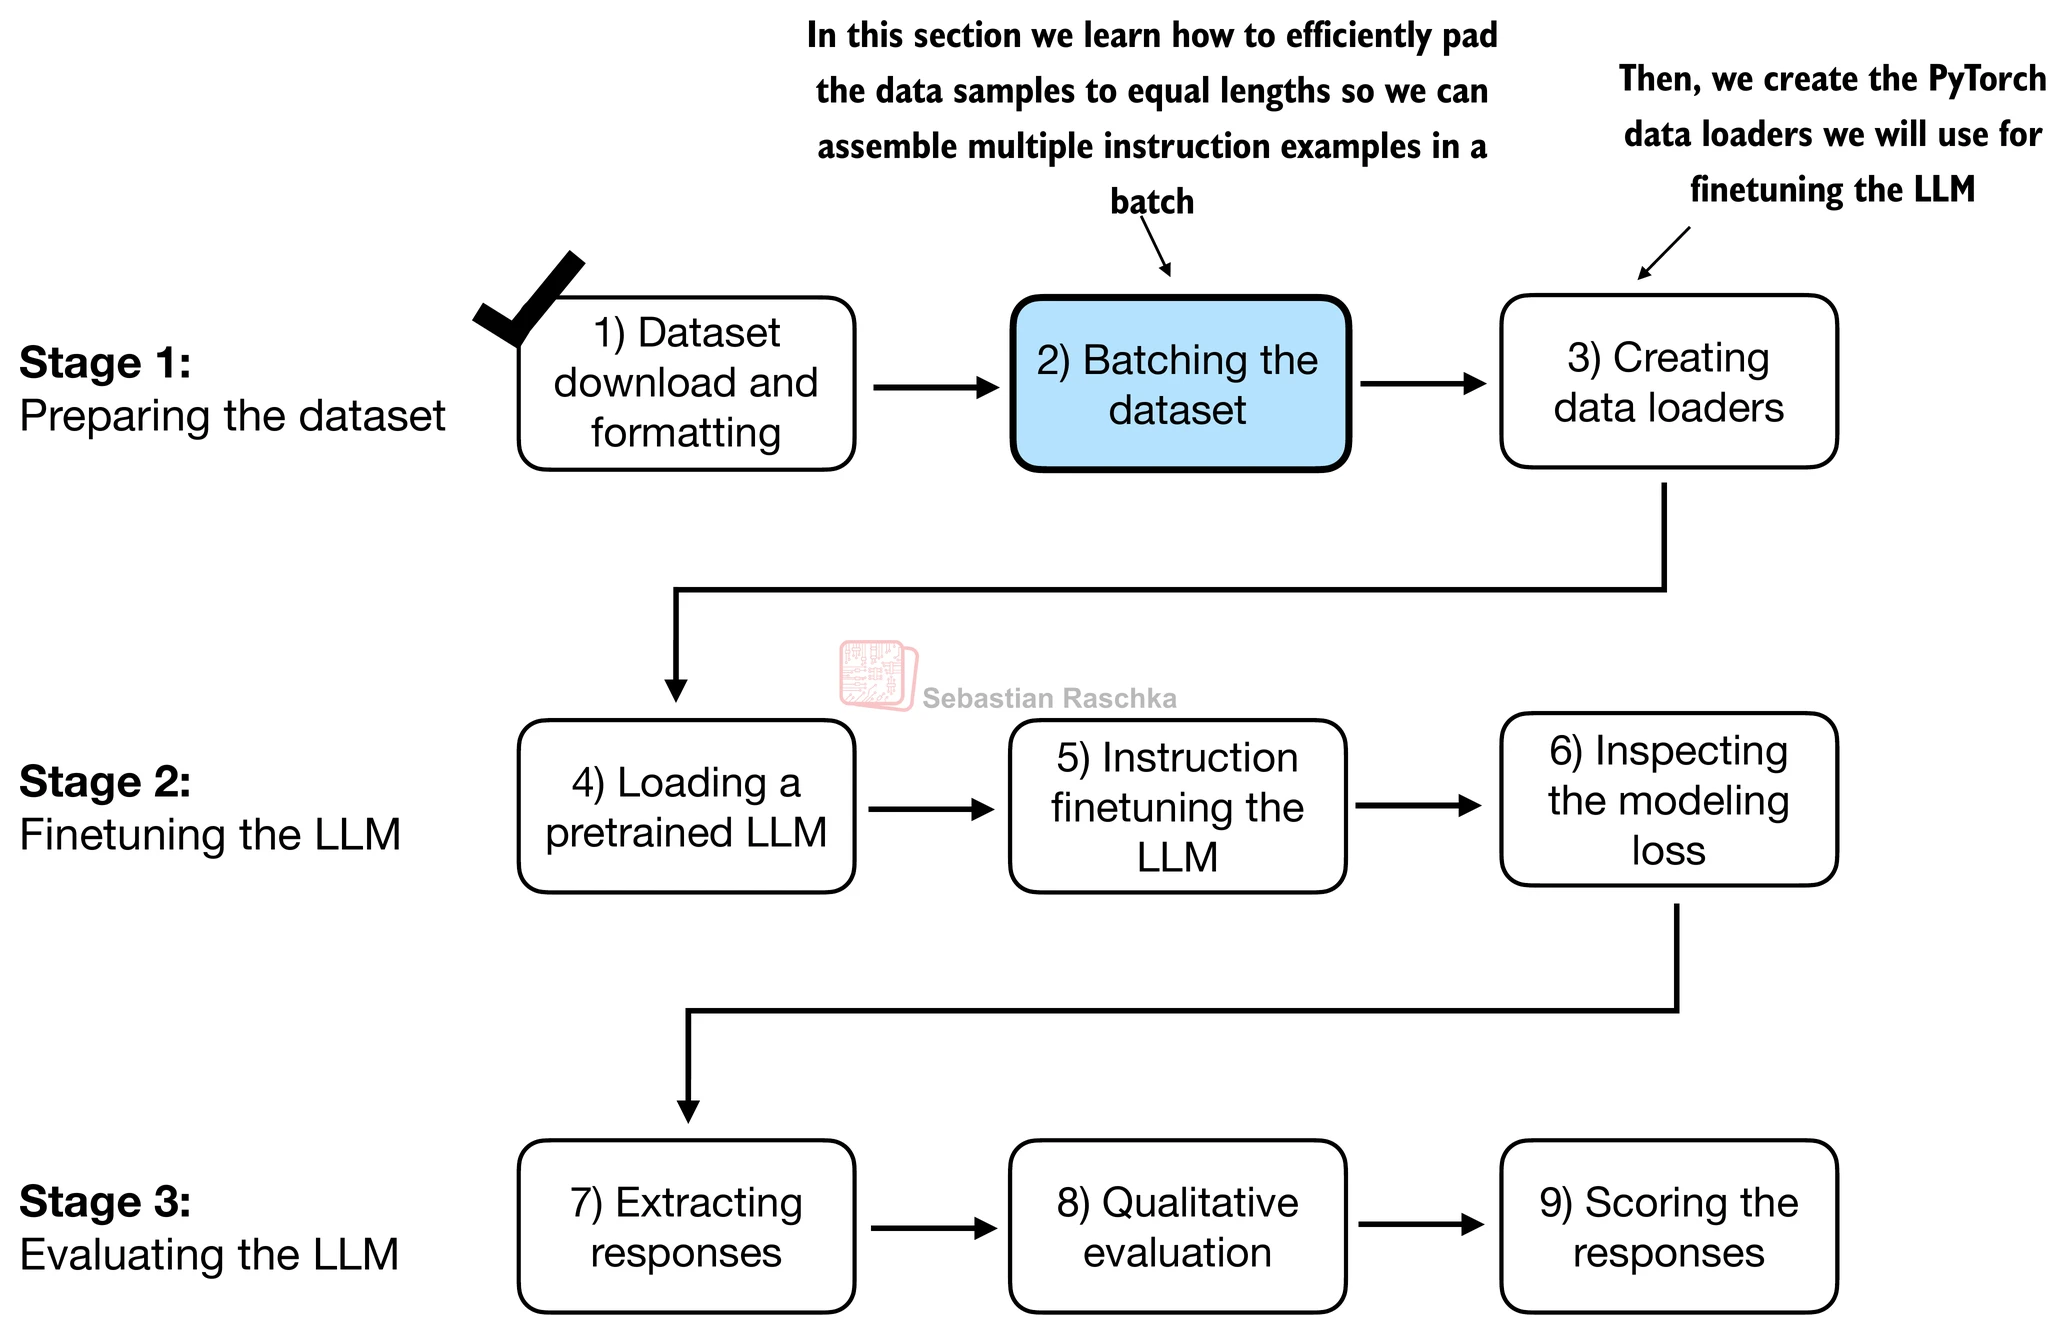
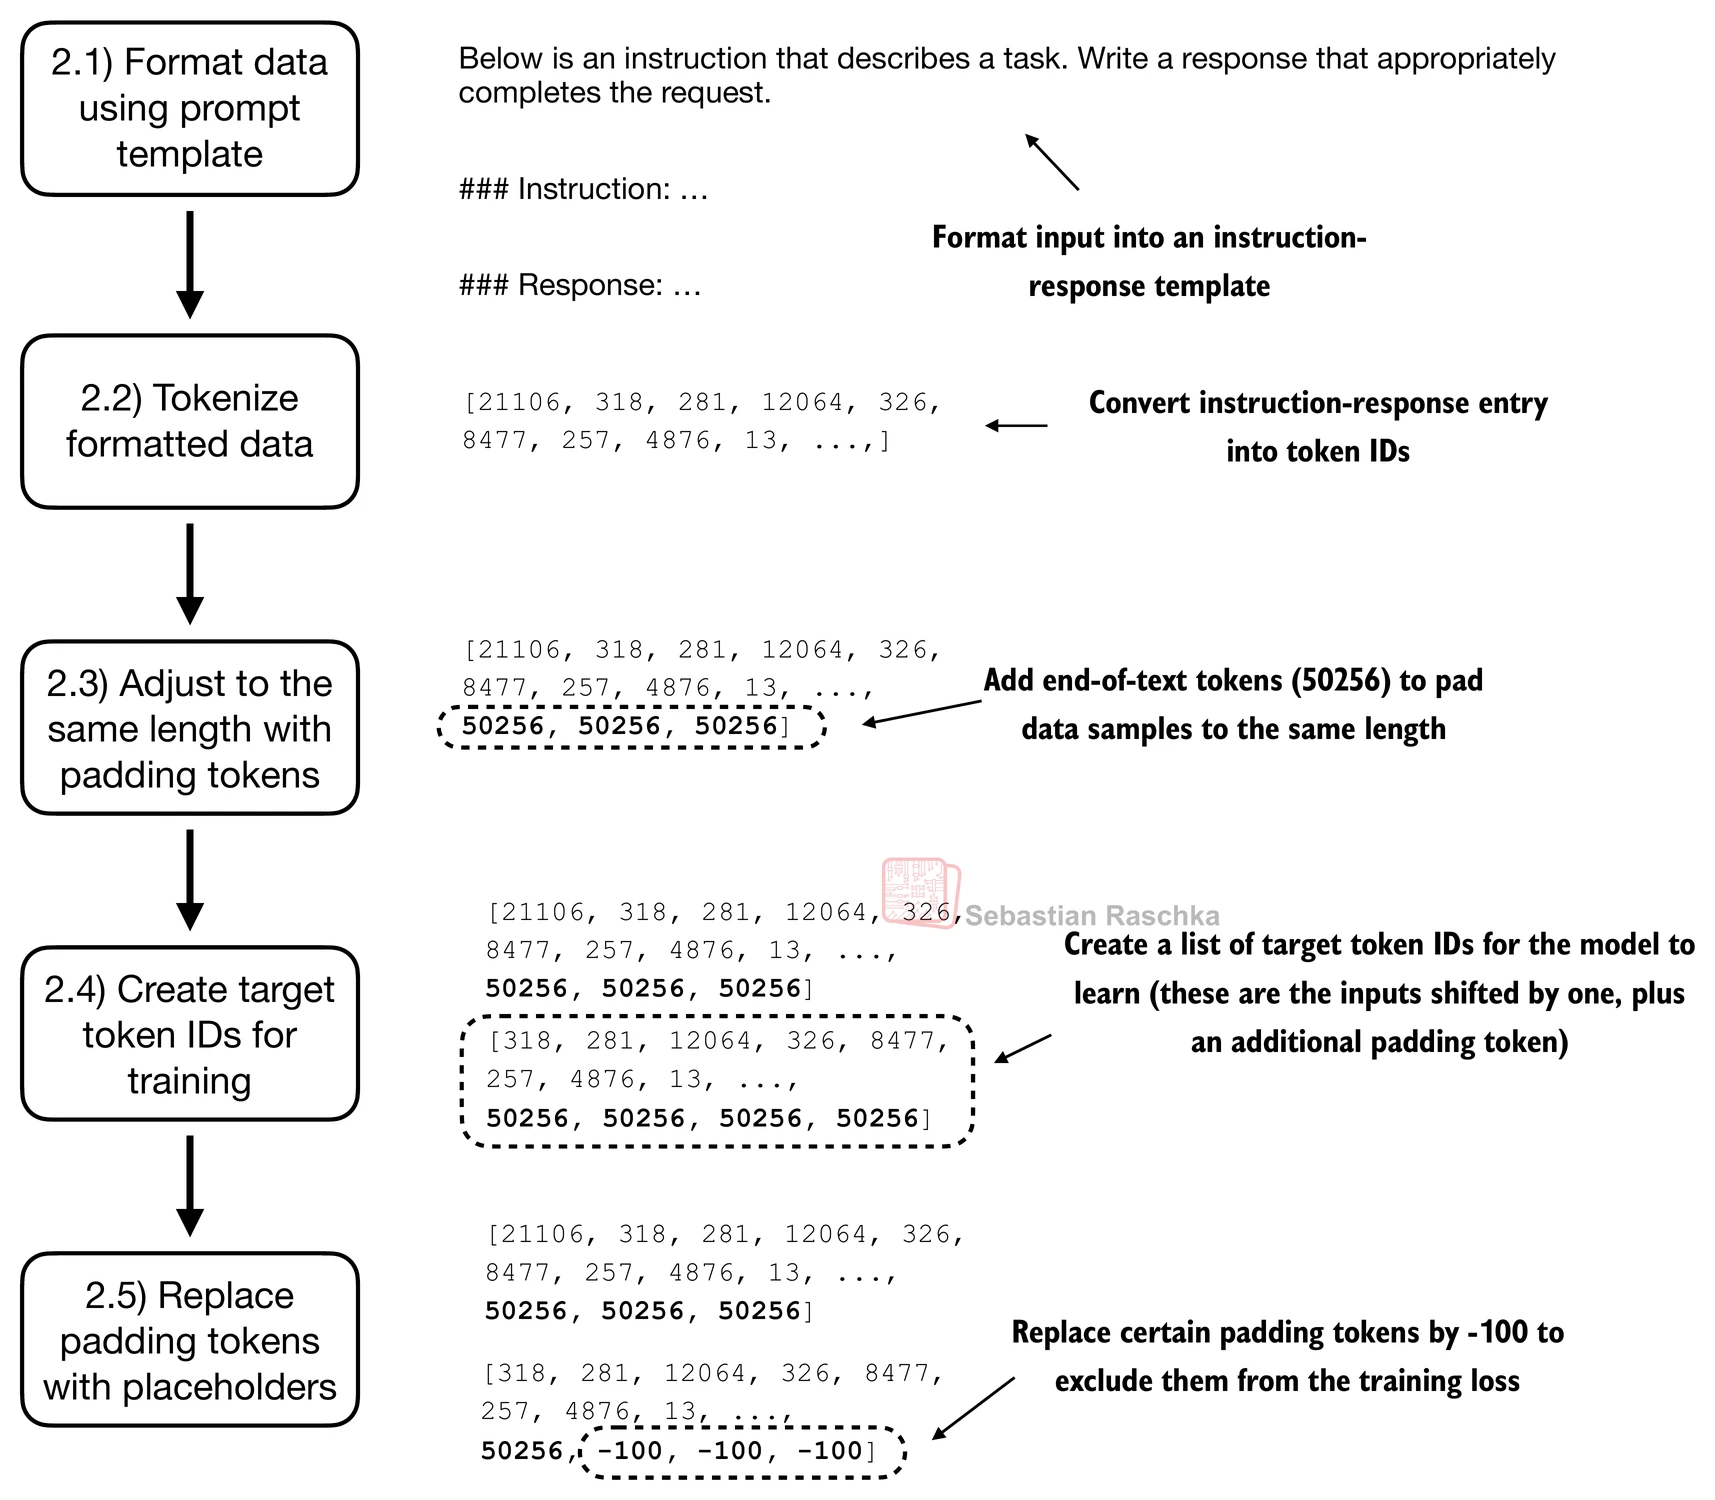
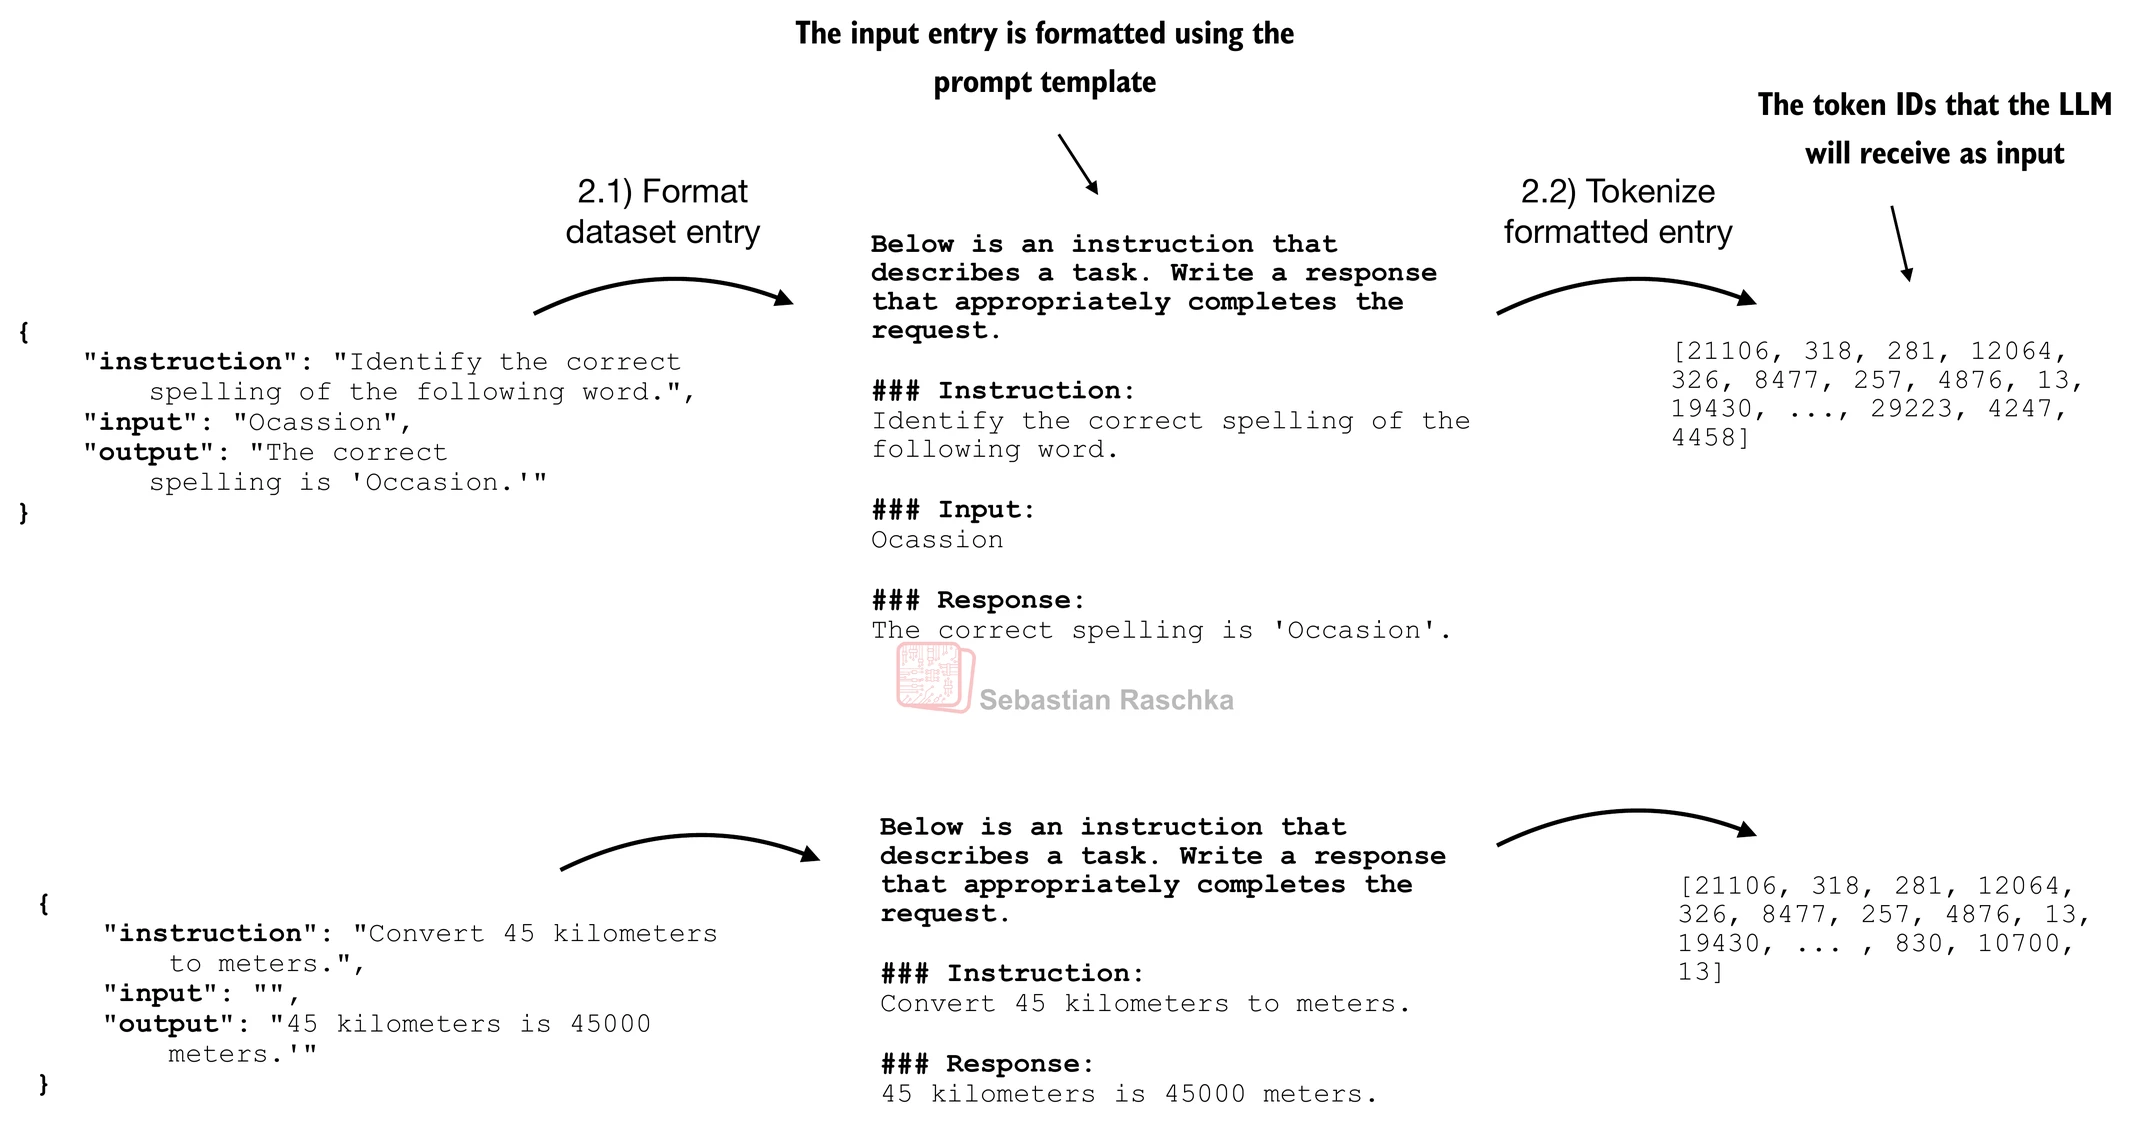

In [ ]:
import torch
from torch.utils.data import Dataset


# 自定义指令微调数据集：在 __init__ 阶段一次性把所有样本格式化并分词（预分词），
# 避免每次 __getitem__ 都重复调用 tokenizer，加快 DataLoader 迭代速度；
# 此处不做 padding，每个样本长度可能不同，padding 留给后面的 collate_fn 在组 batch 时动态完成
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        # 返回的是 token id 组成的 list（未 padding，长度不固定）
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

# 查看 <|endoftext|> 特殊 token 对应的 id，GPT-2 分词器中其 id 为 50256，
# 后续会把它同时用作序列结束符和 padding 填充符
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

In [ ]:
# 第一版简化 collate 函数：只演示 padding 对齐逻辑，尚未生成训练用的 targets
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below
    # batch 内最长序列长度 +1：多留出的这 1 个位置用来放一个 <|endoftext|> 结束符，
    # 下面构造 inputs 时再通过 padded[:-1] 把它裁掉（该多余 token 在后续版本中用于构造 targets）
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # Via padded[:-1], we remove the extra padded token
        # that has been added via the +1 setting in batch_max_length
        # (the extra padding token will be relevant in later codes)
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # Convert list of inputs to tensor and transfer to target device
    # 堆叠成形状为 (batch_size, batch_max_length-1) 的张量
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor
# 用三条不同长度（5/2/3）的样本模拟一个 batch，验证 padding 是否对齐到统一长度
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

In [ ]:
# 第二版 collate 函数：新增 targets（训练标签），采用经典的“语言模型移位”做法——
# inputs 取 padded[:-1]，targets 取 padded[1:]，即 targets 是 inputs 整体右移一位，
# 这样第 t 个位置的 target 就是模型在看到 inputs[:t+1] 后应预测的下一个 token
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs to tensor and transfer to target device
    # inputs_tensor 和 targets_tensor 形状均为 (batch_size, batch_max_length-1)，一一对应
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [ ]:
# 用同一个示例 batch 验证：targets 相比 inputs 整体右移一位，并在末尾补上 pad_token_id
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

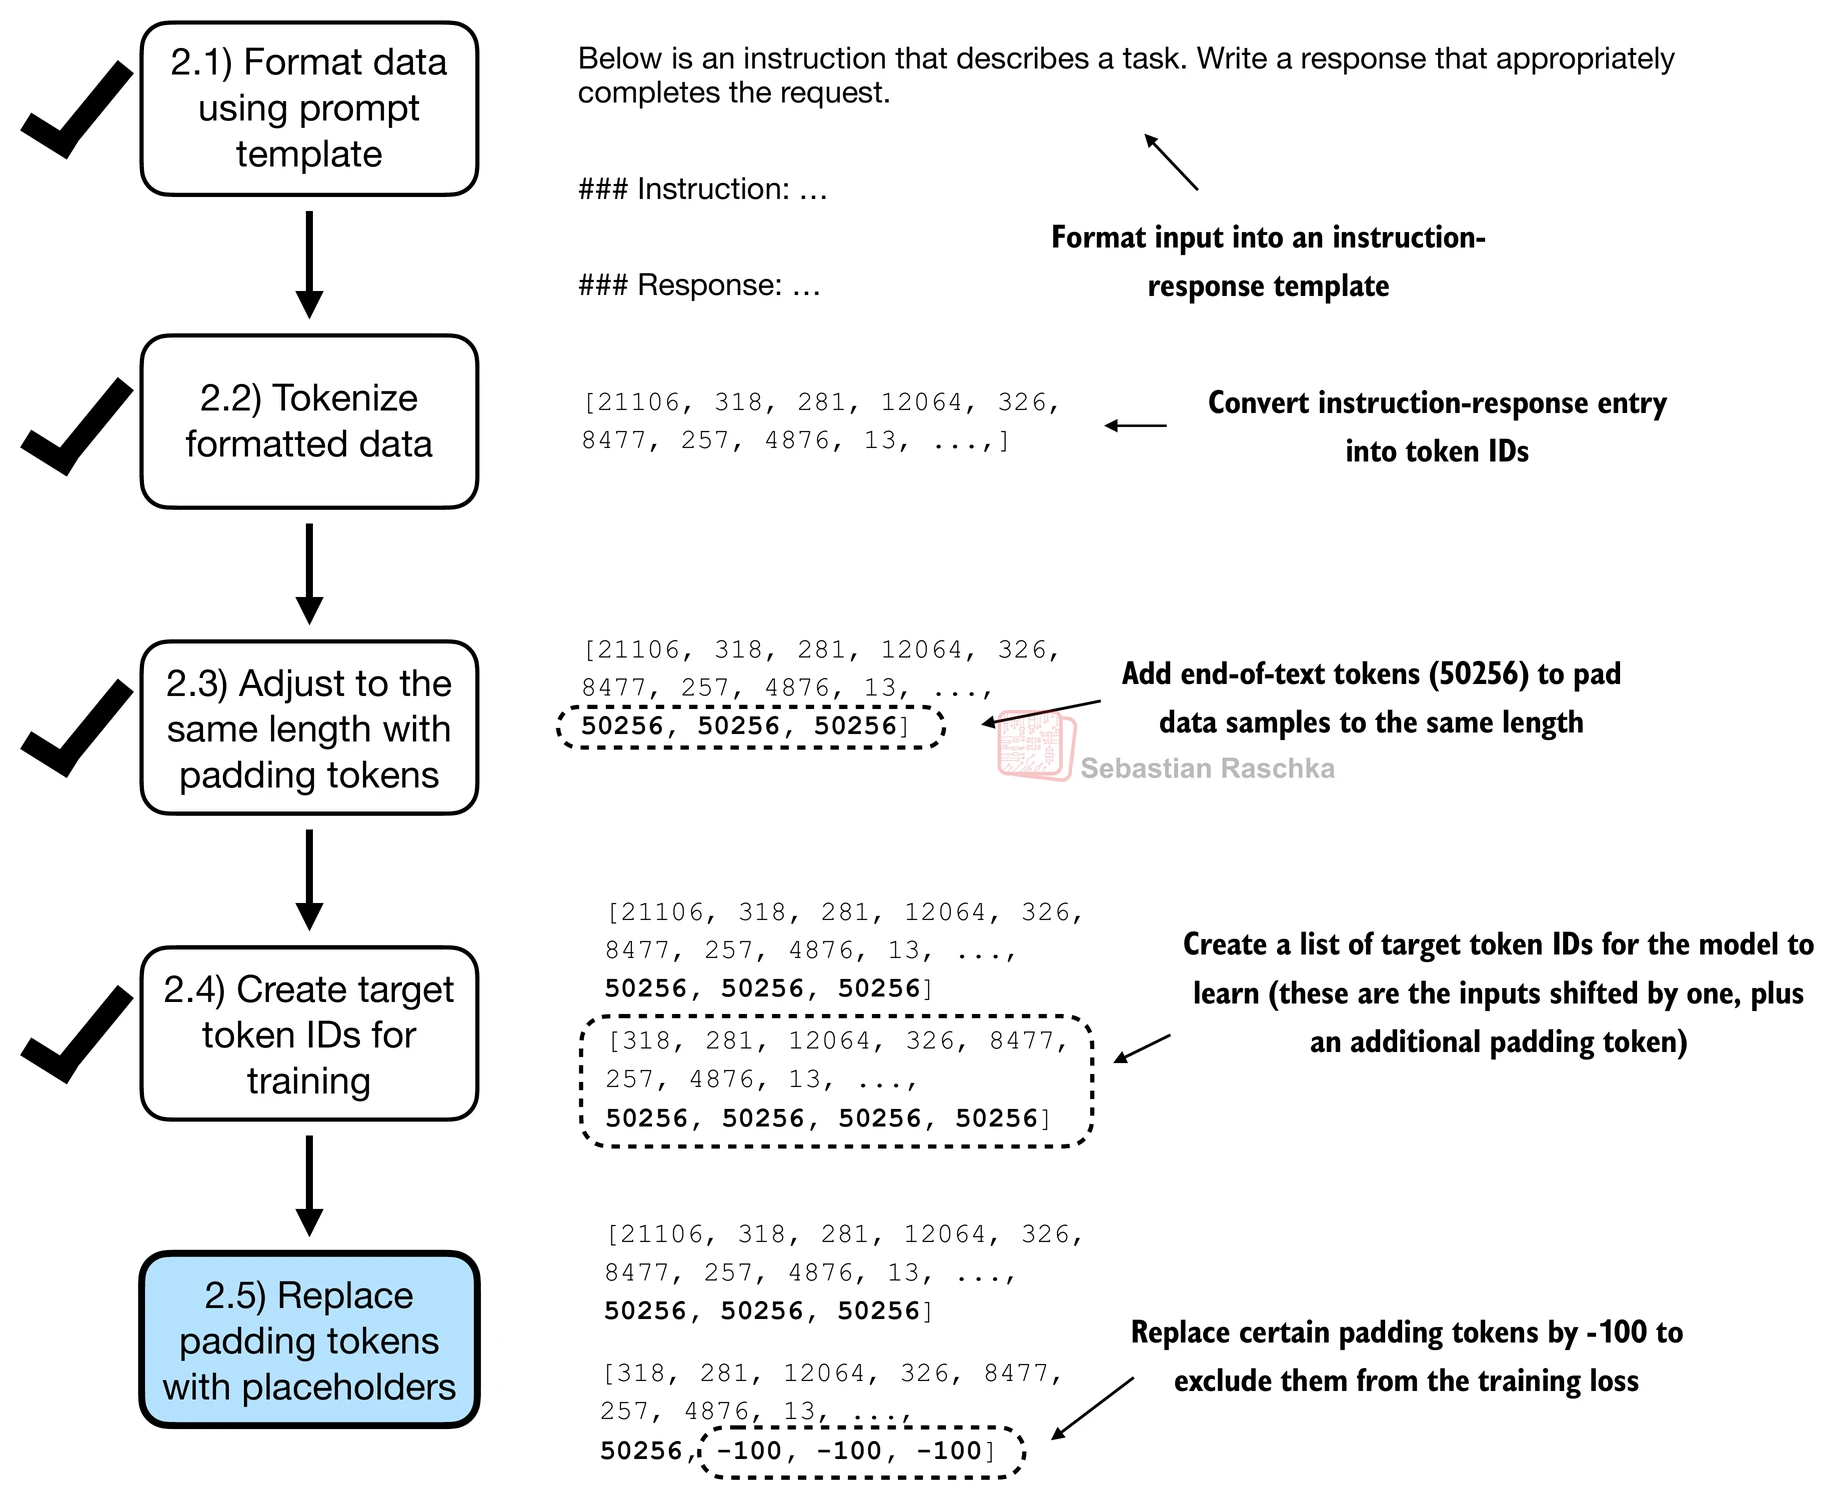
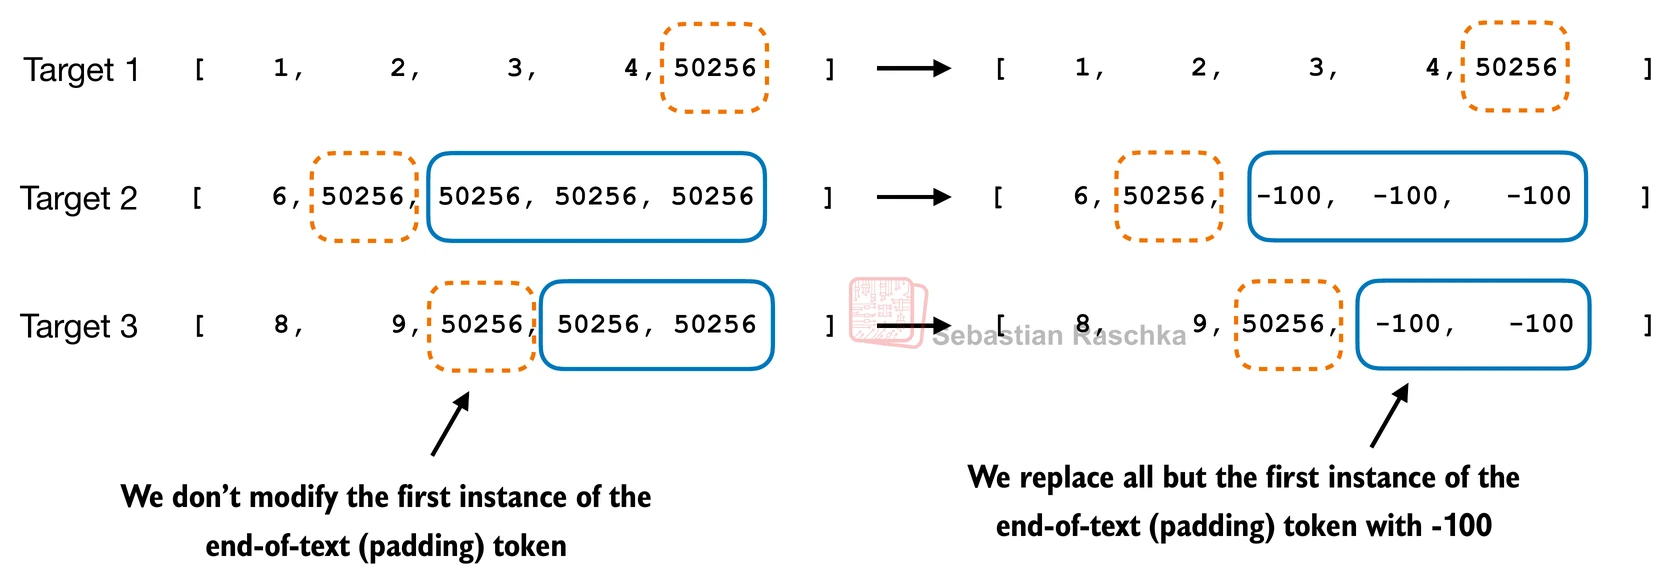

In [ ]:
# 最终版 collate 函数：在 draft_2 基础上新增两个关键改动——
# 1) 用 ignore_index(-100) 掩盖除第一个 padding token 之外的所有 padding，
#    使 cross_entropy 计算损失时自动跳过这些位置（保留 1 个 pad 是为了让模型仍学会何时输出结束符）；
# 2) 可选地把序列截断到 allowed_max_length，防止超出模型的上下文窗口
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        # 找出 targets 中所有等于 pad_token_id 的位置；保留第一个（对应真正的结束符，
        # 应参与损失计算），其余全部替换为 ignore_index，训练时 loss 会自动忽略这些位置
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    # 最终 inputs_tensor / targets_tensor 形状均为 (batch_size, seq_len)，
    # 其中 seq_len 由本批次内最长样本决定（不同 batch 之间 seq_len 可能不同，即“动态 padding”）
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [ ]:
# 验证最终版 collate 函数：targets 中除第一个 pad token 外，其余 padding 位置应变为 -100
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

In [ ]:
# 用一个最简单的两分类例子回顾 cross_entropy 的基本用法：
# logits 形状 (2, 2) 对应 2 个样本、2 个类别；targets 形状 (2,) 为类别索引
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

In [ ]:
# 增加第 3 个样本（logits 与第 2 个样本相同），观察平均损失如何随样本数量变化
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

In [ ]:
# 关键演示：cross_entropy 默认 ignore_index=-100，把第 3 个样本的标签设为 -100 后，
# 该样本会被完全跳过，等价于只用前 2 个样本计算损失（与 loss_1 相同）——
# 这正是上面 custom_collate_fn 中用 -100 屏蔽多余 padding 位置的原理
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

7.4 Creating data loaders for an instruction dataset
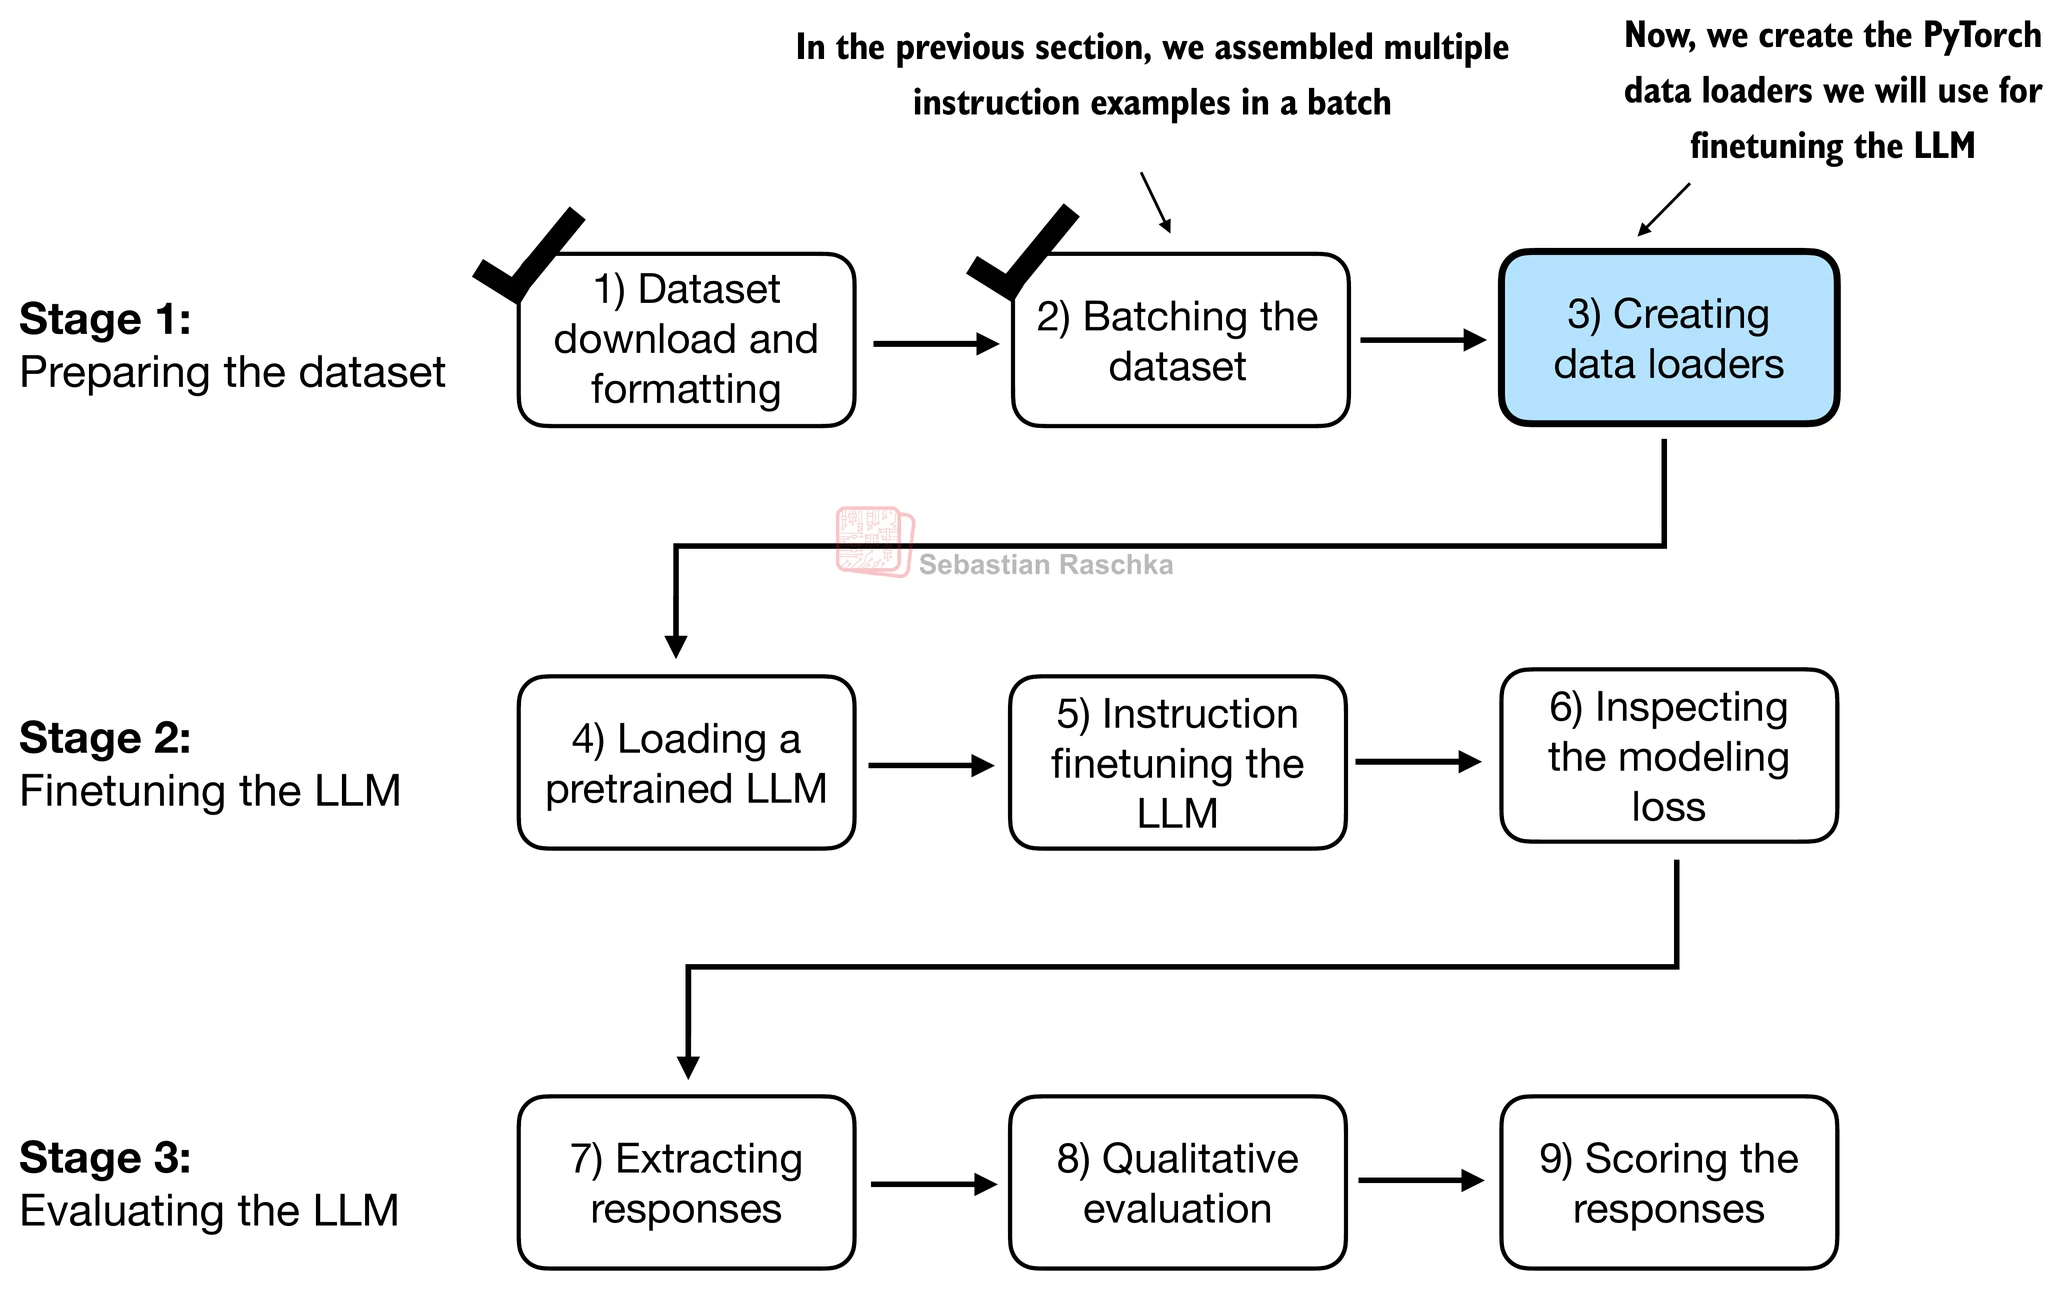

In [ ]:
# 自动选择训练设备：优先 CUDA，其次 Apple Silicon 的 MPS（需 PyTorch >= 2.9 才能保证
# MPS 上的结果稳定，否则回退到 CPU），都不可用时使用 CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

In [ ]:
from functools import partial

# 用 functools.partial 预先固定 collate_fn 的 device 和 allowed_max_length 参数，
# 生成的 customized_collate_fn 可以直接传给 DataLoader（DataLoader 只会传入 batch 这一个位置参数）；
# allowed_max_length=1024 与 GPT-2 的最大上下文长度一致，防止序列过长导致越界
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [ ]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

# 训练集：shuffle=True 打乱顺序，drop_last=True 丢弃不足一个 batch 的尾部数据，
# 每个 batch 内部会通过 customized_collate_fn 动态 padding 到该 batch 的最长序列长度
train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)
# 验证集：不打乱、不丢弃尾批，便于评估时结果可复现
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

# 测试集：同验证集设置，仅用于最终生成/评估，不参与训练
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [ ]:
print("Train loader:")
# 逐批打印 inputs/targets 的形状 (batch_size, seq_len)；由于采用动态 padding，
# 不同 batch 的 seq_len 可能不同（取决于该 batch 内最长样本的 token 数）
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

7.5 Loading a pretrained LLM
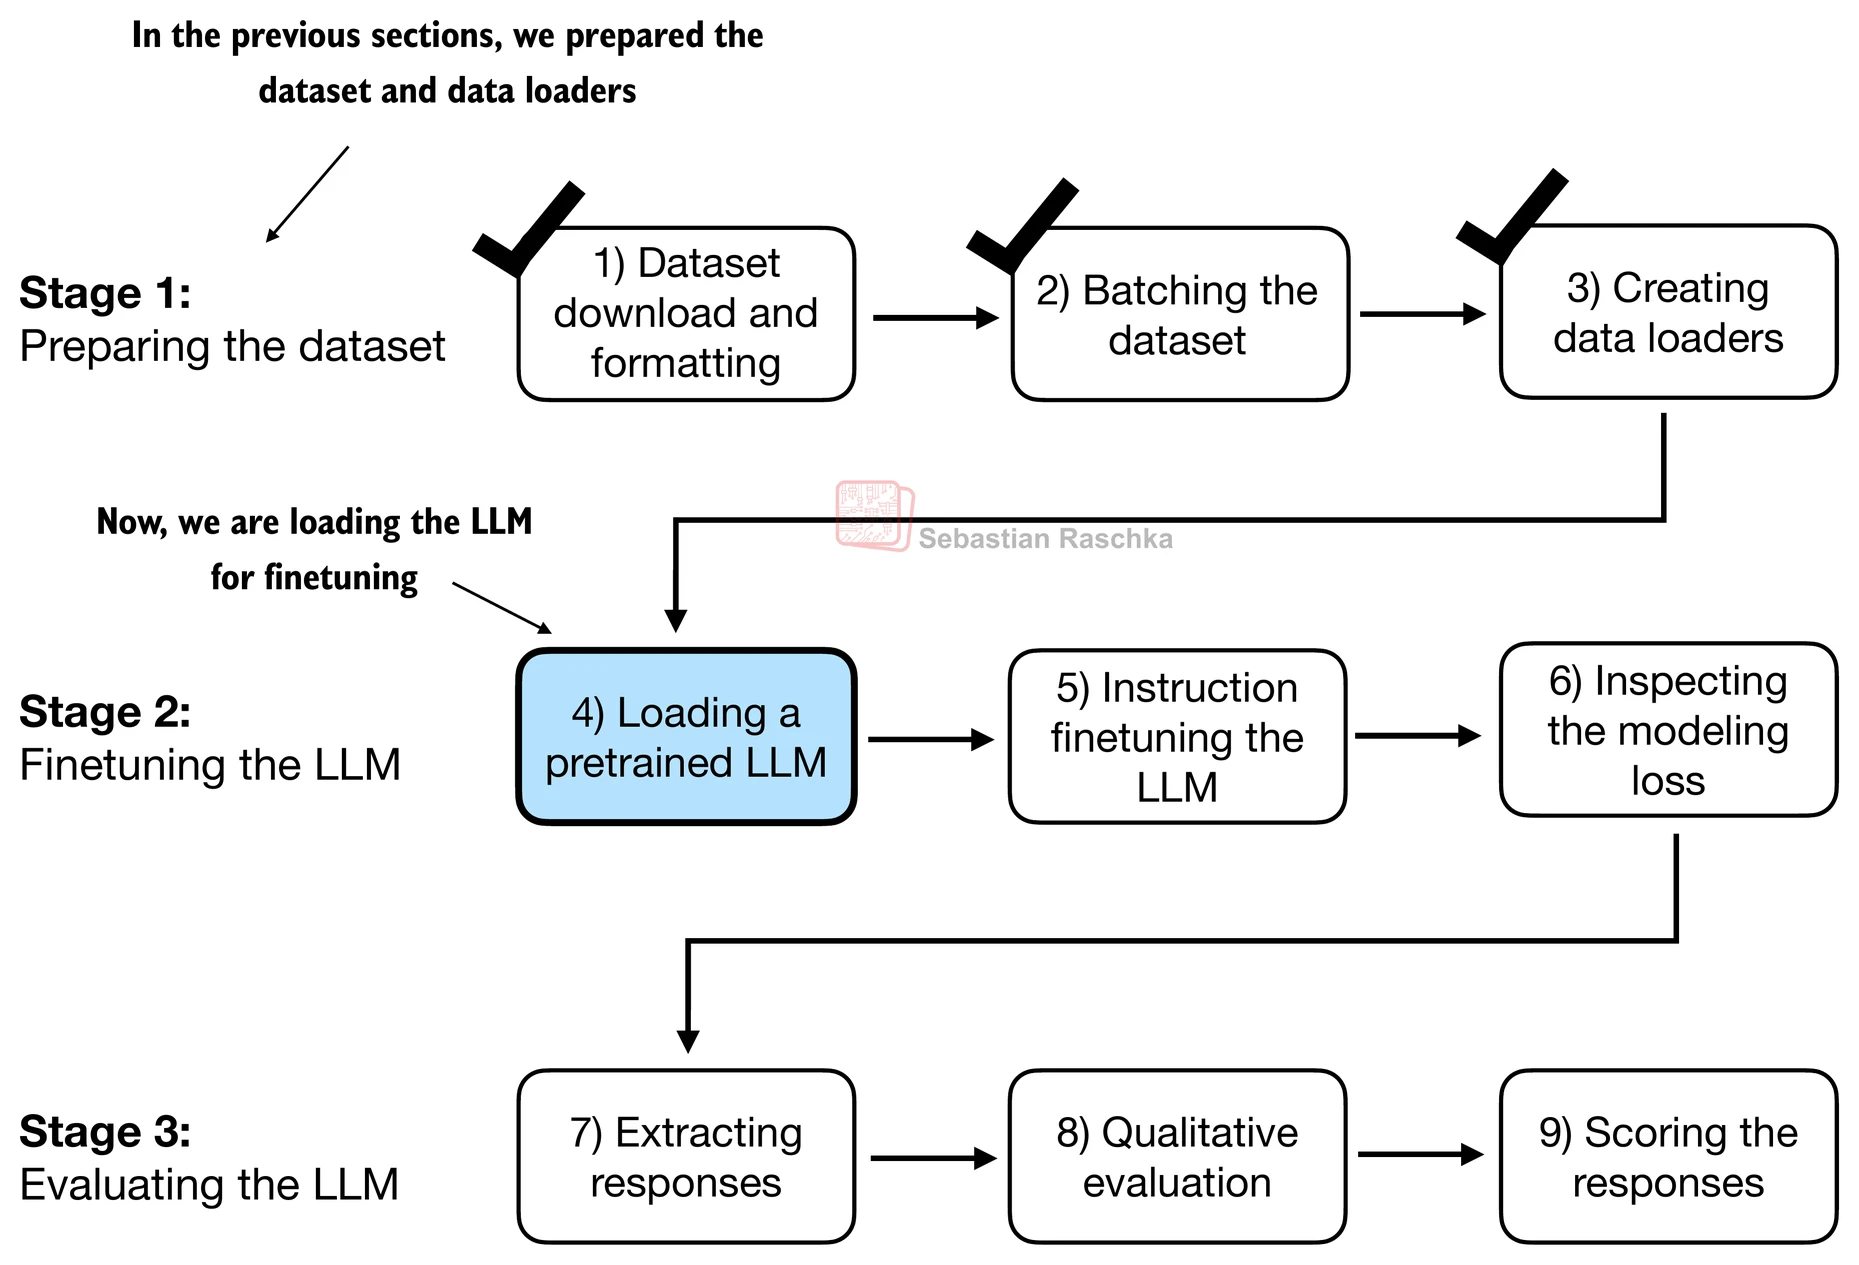


In [ ]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel
# from llms_from_scratch.ch05 import download_and_load_gpt2, load_weights_into_gpt


# 基础模型配置：GPT-2 词表大小、上下文长度，此处 drop_rate=0 表示微调阶段关闭 dropout，
# qkv_bias=True 是为了与 OpenAI 原始 GPT-2 预训练权重的结构保持一致（可正确加载权重）
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

# 四种规格的 GPT-2 模型对应的结构超参数（嵌入维度、层数、注意力头数）
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
# 下载（若本地已有则复用）并加载 OpenAI 发布的 GPT-2 预训练权重
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

# 用上面的配置搭建模型结构，再把预训练权重灌入模型参数；
# model.eval() 关闭 dropout 等训练专用行为，为后续生成/评估做准备（微调阶段会再切回 train 模式）
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

In [ ]:
torch.manual_seed(123)

# 用验证集第一条样本构造 prompt，先看看“仅预训练、未微调”的模型会怎样续写指令
input_text = format_input(val_data[0])
print(input_text)

In [ ]:
from previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)
# Alternatively:
# from llms_from_scratch.ch05 import (
#    generate,
#    text_to_token_ids,
#    token_ids_to_text
# )


# 微调前的基线生成：用贪心/采样解码（沿用第 5 章的 generate 函数）续写最多 35 个新 token，
# 遇到 eos_id(50256, 即 <|endoftext|>) 提前停止
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [ ]:
# 从生成文本中截掉原始 prompt 部分，只保留模型新生成的回答，并去掉模板中的 "### Response:" 标记；
# 由于模型尚未微调，此时的回答通常质量较差（可能只是在重复或胡乱续写）
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

7.6 Finetuning the LLM on instruction data
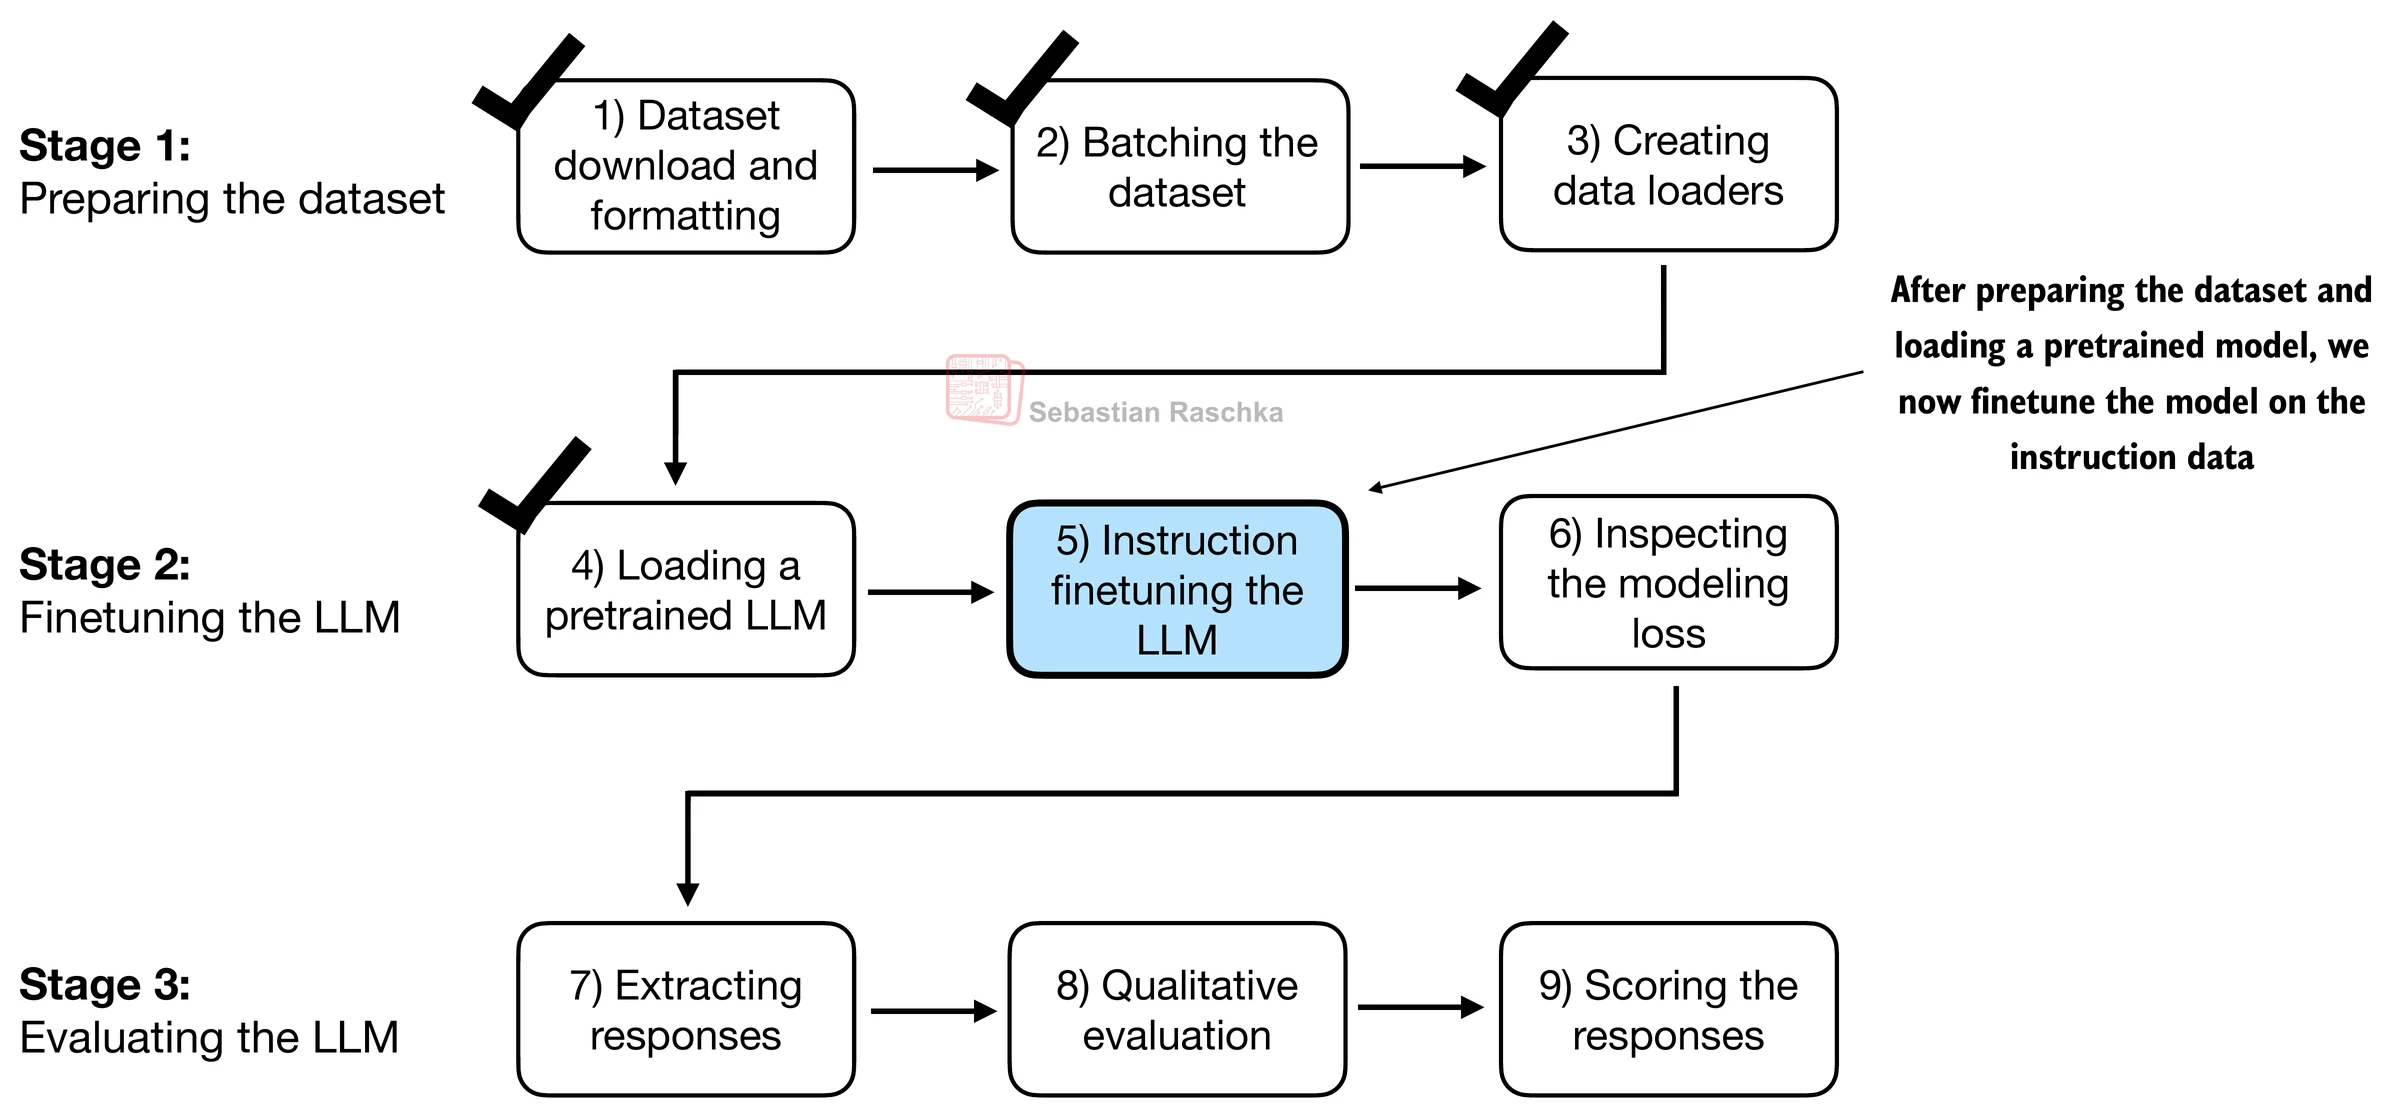

In [ ]:
# 复用第 5 章实现的 calc_loss_loader（计算 DataLoader 上的平均损失）
# 和 train_model_simple（通用训练循环：前向、反向、优化器更新、周期性评估与采样打印）
from previous_chapters import (
    calc_loss_loader,
    train_model_simple
)
# Alternatively:
# from llms_from_scratch.ch05 import (
#    calc_loss_loader,
#    train_model_simple,
# )

In [ ]:
model.to(device)

torch.manual_seed(123)

# 微调前先测量训练集/验证集损失作为基线（只抽样 5 个 batch 以加快速度，not the full loss）；
# torch.no_grad() 关闭梯度追踪，纯前向计算，节省显存和时间
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)



In [ ]:
import time

start_time = time.time()

torch.manual_seed(123)

# AdamW 优化器，学习率 5e-5（比预训练阶段小很多，微调时应使用更小的学习率以免破坏预训练知识），
# weight_decay=0.1 做 L2 正则化
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

# 正式开始指令微调：train_model_simple 内部循环遍历 train_loader，每个 batch 做前向 + 反向 + 优化；
# 每 eval_freq 步在训练/验证集上各抽样 eval_iter 个 batch 计算损失并记录，
# 同时以 start_context 为 prompt 生成一段文本，直观查看模型效果的演变
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

In [ ]:
from previous_chapters import plot_losses
# Alternatively:
# from llms_from_scratch.ch05 import plot_losses

# 绘制训练/验证损失随 epoch（下轴）和已训练 token 数（上轴）变化的曲线，
# 用于判断是否收敛、是否过拟合（验证损失回升）
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

7.7 Extracting and saving responses
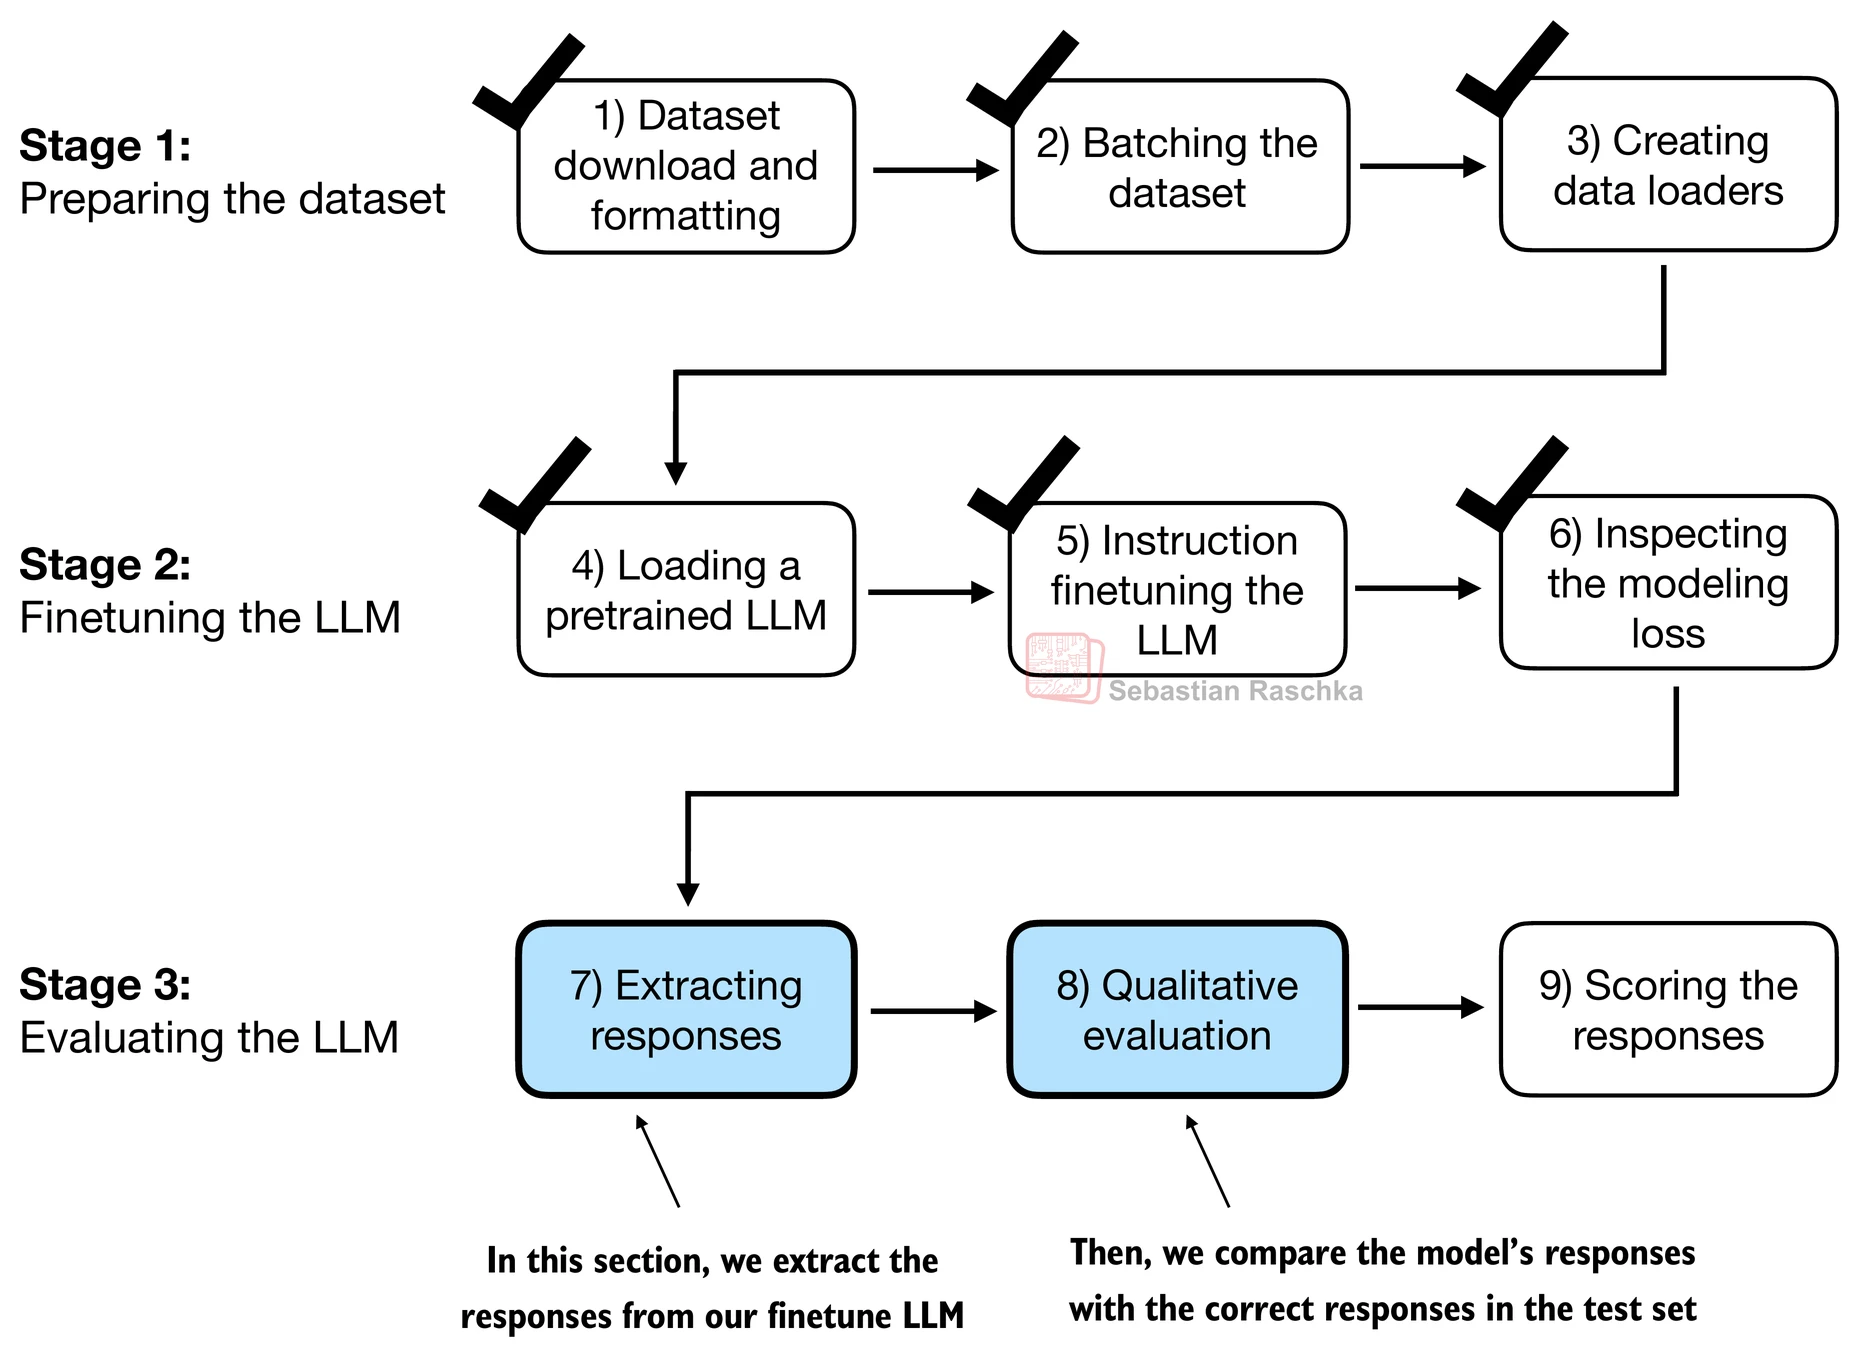

In [ ]:
torch.manual_seed(123)


# 微调完成后，在测试集前 3 条样本上生成回答，与数据集中的参考答案（correct response）逐条对比，
# 直观检查微调效果；max_new_tokens 加大到 256 以容纳更长的回答
for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

In [ ]:
from tqdm import tqdm

# 对整个测试集批量生成回答（用 tqdm 显示进度条，耗时较长），
# 并把生成结果写回每条样本的 "model_response" 字段，方便后续统一评估
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


# 把带有模型回答的完整测试集保存为 JSON 文件，供后续（7.7 节）用 Ollama/llama3 做自动化评分
with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

In [ ]:
import re


# 保存微调后的模型权重（state_dict），文件名根据所选模型规格自动生成，
# 例如 "gpt2-medium355M-sft.pth"（sft = supervised fine-tuning）
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

7.8 Evaluating the finetuned LLM
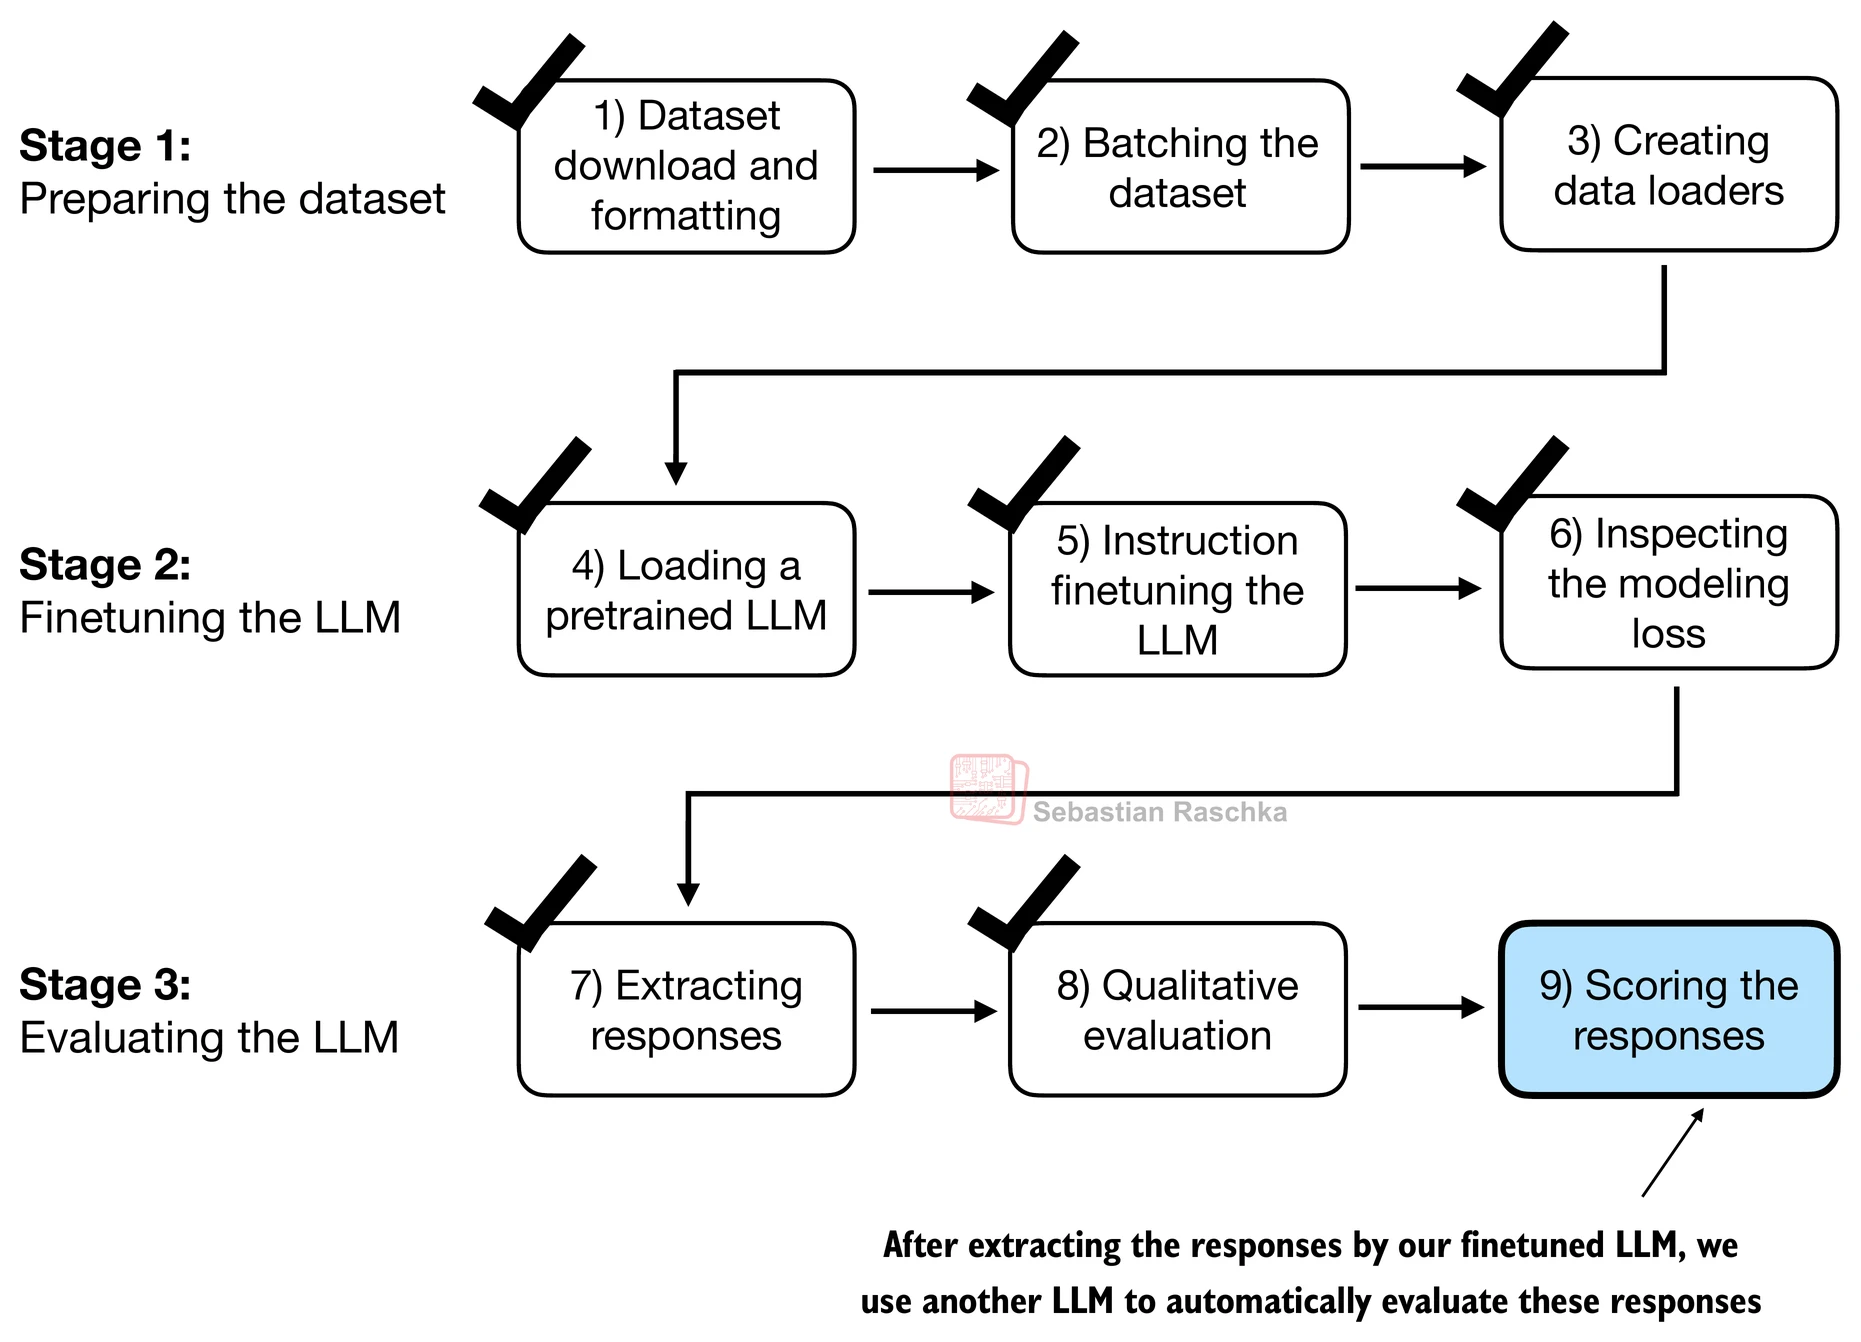

In [ ]:
import psutil

# 通过遍历系统进程列表，检查名称中包含 "ollama" 的进程是否在运行，
# 因为 7.7 节要用本地 Ollama 服务（运行 llama3 模型）对微调结果做自动化评分
def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

In [ ]:
# This cell is optional; it allows you to restart the notebook
# and only run section 7.7 without rerunning any of the previous code
# 可选的“重启入口”单元：如果只想单独运行 7.7 节的自动评估部分，
# 可以重启内核后直接从这里开始，无需重新执行前面耗时的微调过程——
# 直接从磁盘加载 42 号单元保存的带 model_response 的测试集，并重新定义 format_input
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [ ]:
import requests  # noqa: F811
# import urllib.request

# 定义与本地 Ollama 服务交互的函数：把 prompt 包装成 chat 消息发送给指定模型（默认 llama3），
# 设置 seed/temperature=0 以获得确定性（可复现）的输出
def query_model(
    prompt,
    model="llama3",
    # If you used OLLAMA_HOST=127.0.0.1:11435 ollama serve
    # update the address from 11434 to 11435
    url="http://localhost:11434/api/chat"
):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }


    """
    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")

    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data
    """

    # The book originally used the commented-out above, which is based
    # on urllib. It works generally fine, but some readers reported
    # issues with using urlib when using a (company) VPN.
    # The code below uses the requests library, which doesn't seem
    # to have these issues.

    # Send the POST request
    # 以流式方式（stream=True）发送 POST 请求：Ollama 会按行返回 NDJSON（每行一个 JSON 对象），
    # 逐行解析并拼接 message.content 字段，得到模型的完整回复文本
    with requests.post(url, json=data, stream=True, timeout=30) as r:
        r.raise_for_status()
        response_data = ""
        for line in r.iter_lines(decode_unicode=True):
            if not line:
                continue
            response_json = json.loads(line)
            if "message" in response_json:
                response_data += response_json["message"]["content"]

    return response_data


model = "llama3"
# 简单测试一下 query_model 是否能正常访问本地 Ollama 服务
result = query_model("What do Llamas eat?", model)
print(result)

In [ ]:
# 用 llama3 对前 3 条测试样本的模型回答做定性打分演示：把 instruction/正确答案/模型回答
# 一起塞进评分 prompt，让 llama3 给出 0~100 的评分（此处评分格式还比较自由，未强制纯数字）
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")

In [ ]:
# 批量自动评分函数：对 json_data 中每条样本调用 query_model 打分，
# 提示词末尾明确要求“只回复整数”，便于用 int() 解析；解析失败则打印警告并跳过该条
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


# 对整个测试集的 model_response 打分，最终打印成功评分的数量及平均分，
# 作为该指令微调模型的一个自动化质量指标（LLM-as-judge）
scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

7.9 Conclusions


7.9.1 What's next

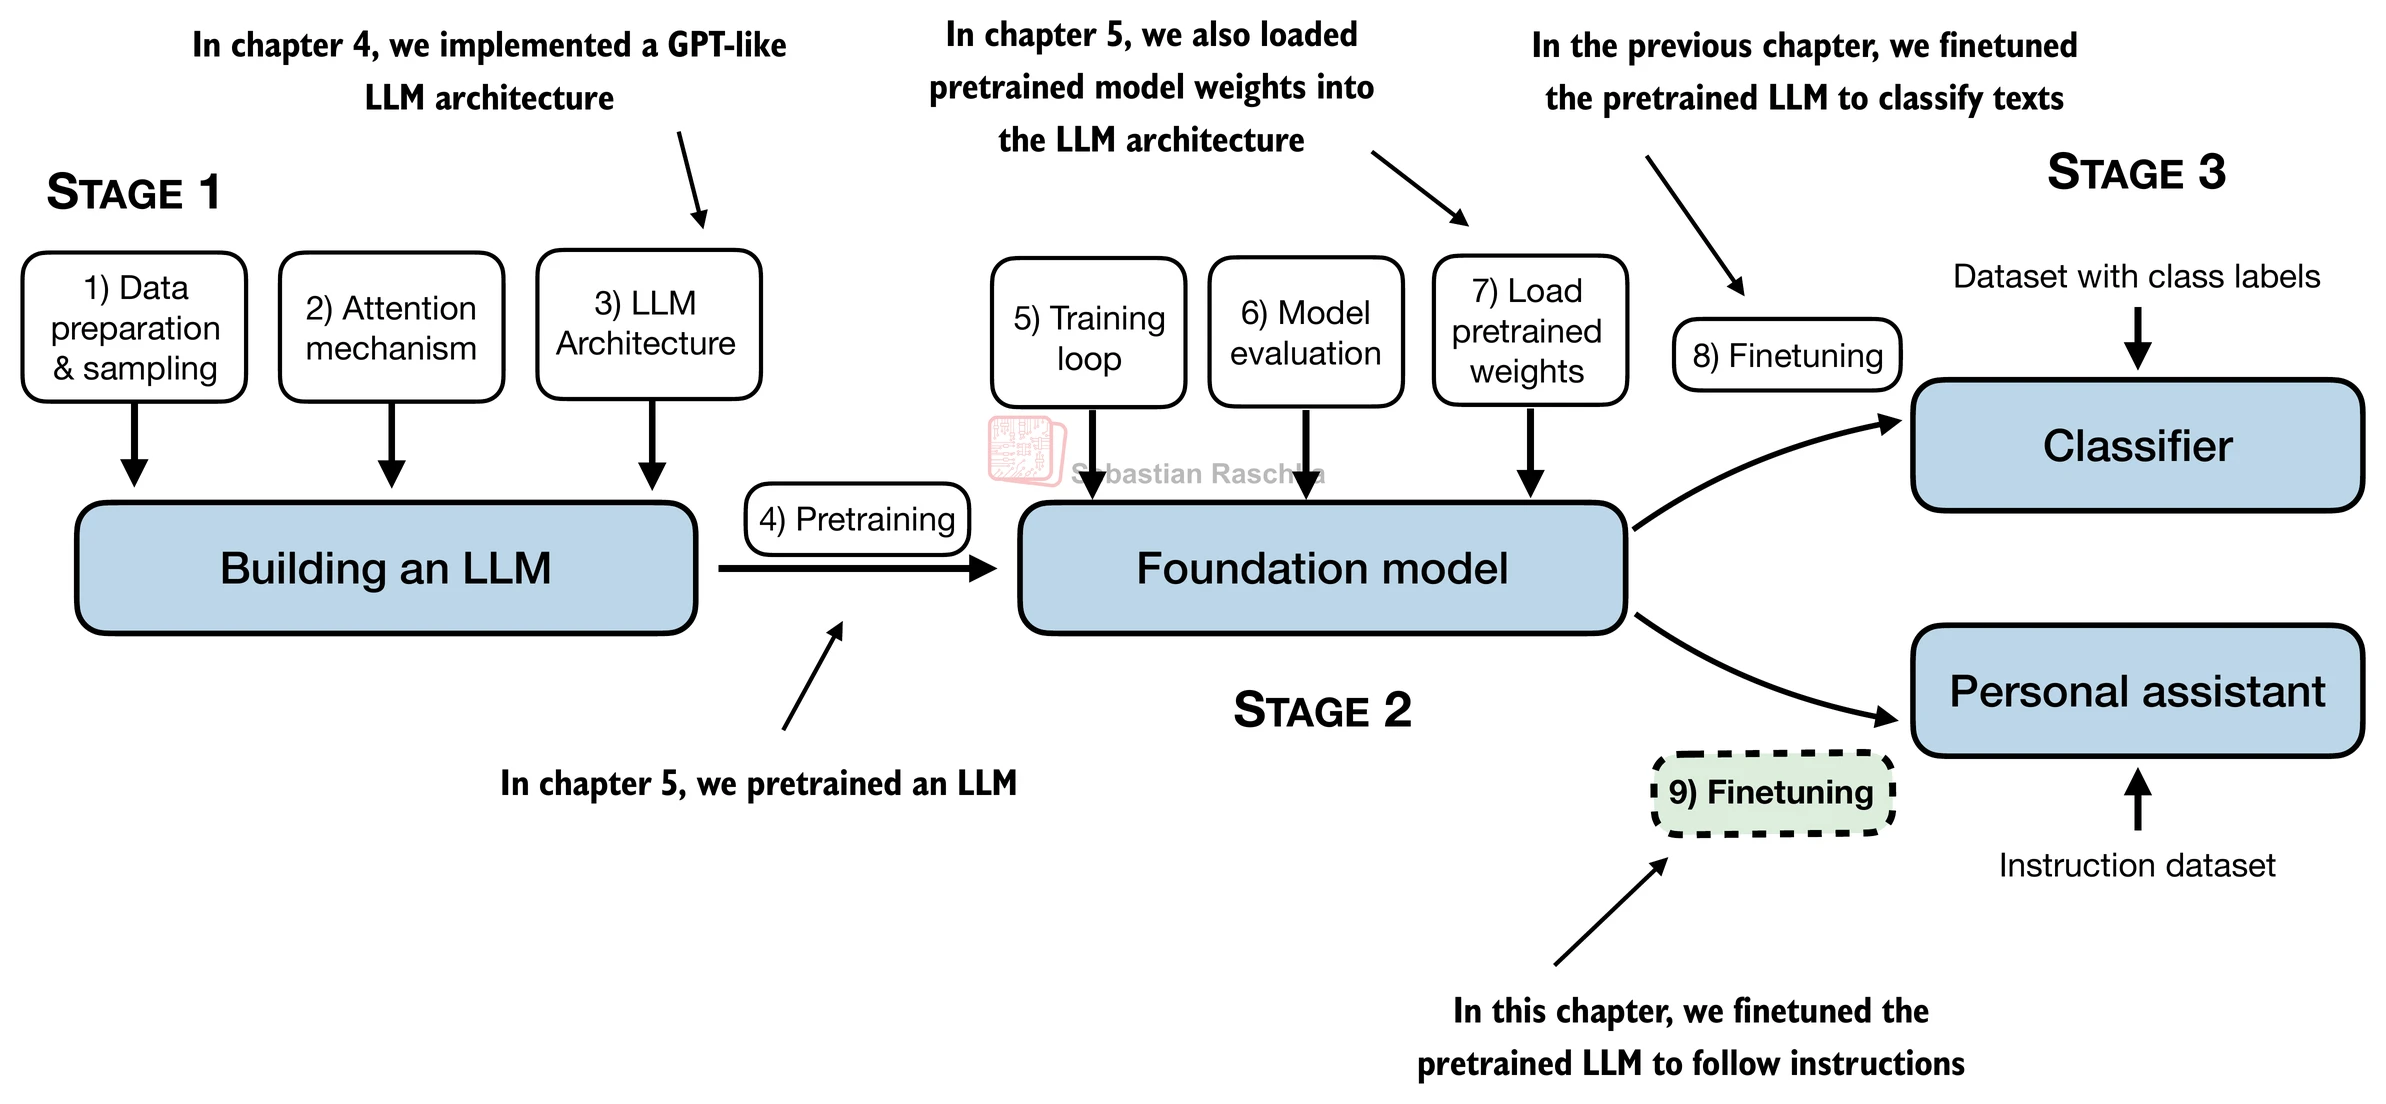

7.9.2 Staying up to date in a fast-moving field
No code in this section


7.9.3 Final words